In [1]:
import shap

import pickle

# Load Data & Model

In [2]:
### Main
dataset_name = "CD"

isample = 566
lambda1 = 1.0
# lambda2 = 0.0
# lambda2 = 1.0
lambda2 = 1.4


weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Weights/set-{isample}-epoch3-lambda1_1.0-lambda2_{lambda2}-added.pth"

log_f = "../log/test_SHAP.log"


In [2]:
### Main
dataset_name = "HateSpeech"

isample = 566
lambda1 = 1.0
# lambda2 = 0.0
lambda2 = 1.0

weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Weights/set-{isample}-epoch3-lambda1_1.0-lambda2_{lambda2}-added.pth"

log_f = "../log/test_SHAP.log"


In [2]:
### Main  - Reverse
dataset_name = "CD"

isample = 6621
lambda1 = 1.0
lambda2 = 0.0
lambda2 = 1.0
# lambda2 = 1.4


weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Weights_ReverseSource/set-{isample}-epoch3-lambda1_1.0-lambda2_{lambda2}-added.pth"

log_f = "../log/test_SHAP.log"


In [3]:
## for predicting Provenance

dataset_name = "CD"

isample = 566

weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Source-set-{isample}-epoch3/pytorch_model.bin"

log_f = "../log/test_SHAP.log"

In [4]:
dataset_name = "HateSpeech"

isample = 6621
lambda1 = 1.0
lambda2 = 0.0
# lambda2 = 1.0

weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Weights_ReverseSource/set-{isample}-epoch3-lambda1_1.0-lambda2_{lambda2}-added.pth"

In [2]:
## for predicting Provenance

dataset_name = "HateSpeech"

isample = 6621


weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Reverse-Source-set-{isample}-epoch3/pytorch_model.bin"

log_f = "../log/test_SHAP.log"

In [2]:
dataset_name = "SHAC"

isample = 11063
lambda1 = 1.0
lambda2 = 0.0
# lambda2 = 1.0

weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Weights_ReverseSource/set-{isample}-epoch3-lambda1_1.0-lambda2_{lambda2}-added.pth"

In [15]:
## for predicting Provenance

dataset_name = "SHAC"

isample = 11063


weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}/n200/Reverse-Source-set-{isample}-epoch3/pytorch_model.bin"

log_f = "../log/test_SHAP.log"

In [3]:
class Args:
    model_name='roberta-base'
    weightsEdited = weightsEdited
    output_dir="~/Downloads/tmp"
    gpu="3"
    device="cuda:0"
    batch_size=8
    dataset=dataset_name

In [4]:
args = Args()

In [5]:
import os
import argparse

os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu

import sys

sys.path.append("../src")
sys.path.append("../config")

from data_process import load_wls_adress_AddDomain
from process_SHAC import load_process_SHAC
from process_CD import load_cd
from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from sampling_numbers import HateSpeech_DICT, SHAC_DICT, CD_DICT

from tqdm.auto import tqdm
import numpy as np
import pandas as pd

import torch
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)
from scipy.special import softmax
from accelerate.utils import load_and_quantize_model
# from accelerate.utils import BnbQuantizationConfig

In [6]:
class train_config:
    def __init__(self):
        self.quantization: bool = False


# tmp = [x for x in args.weightsEdited.split("/") if "set-" in x]
# # of form like set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added.pth
# name_pre = tmp[0].split(".pth")[0]
# # 7, 13, 70
# outdir = args.output_dir
# name_general = f"runningInferenceOnly"
# log_f = f"../log/{name_general}.log"

# os.makedirs(outdir, exist_ok=True)

globalconfig = train_config()
globalconfig.model_name = args.model_name
globalconfig.max_seq_length = 512
globalconfig.device = args.device

##### Tokenizer
tokenizer = AutoTokenizer.from_pretrained(globalconfig.model_name, use_fast=False)

# if args.cpuOps:
#     load_device = "cpu"
#     load_state_device = "cpu"
# else:
#     load_device = globalconfig.device
#     load_state_device = globalconfig.device
load_device = globalconfig.device
load_state_device = globalconfig.device

##### Load Model and  Update using Edited Weights
model = AutoModelForSequenceClassification.from_pretrained(
    globalconfig.model_name,
    use_safetensors=False,
)

# this step cannot be ignored here...
model.load_state_dict(
    torch.load(
        args.weightsEdited,
        map_location=load_state_device,
        # map_location=lambda storage, loc: storage,
    )
)

model = model.to(globalconfig.device)

print("###  Finished Loading...")

# if args.quantization:
#     bnb_quantization_config = BnbQuantizationConfig(
#         load_in_8bit=True, llm_int8_threshold=6
#     )
#     model = load_and_quantize_model(
#         model,
#         weights_location=args.weightsEdited,
#         bnb_quantization_config=bnb_quantization_config,
#         device_map=load_device,
#     )

# print("###  Finished Quantization...")

/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###  Finished Loading...


In [7]:
if dataset_name == "CD":
    df_all = load_cd()
    df_avh = df_all["avh"]
    df_r56 = df_all["r56"]

    txt_col = "text"

    z_Categories = ["avh","r56"] 

    labels = ["Negative", "Positive"]
    
elif dataset_name == "HateSpeech":
    df_dynGen = load_HateSpeech_dynGen()
    df_wsf = load_HateSpeech_wsf()

    txt_col = "text"
    
    z_Categories = ["dynGen","wsf"] 

    labels = ["Negative", "Positive"]

elif dataset_name == "SHAC":
#     df_dynGen = load_HateSpeech_dynGen()
#     df_wsf = load_HateSpeech_wsf()

    df_shac = load_process_SHAC(replaceNA="all")
    domain_col = "location"
    label = "Drug"

    df_shac = load_process_SHAC(replaceNA="all")
    df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x[label] else 0, axis=1)
    df_shac["dfSource"] = df_shac[domain_col]
    
    df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
    df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)
        
    txt_col = "text"
    
    z_Categories = ["uw", "mimic"] 

    labels = ["Negative", "Positive"]

In [8]:
def do_Inference(txts):
    df_in = tokenizer(
        list(txts),
        return_tensors="pt",
        max_length=globalconfig.max_seq_length,
        padding="max_length",
        truncation=True,
    )

    y_ls = []
    lst = list(range(len(df_in["input_ids"])))
    n = args.batch_size
    idx_ls = [lst[i : i + n] for i in range(len(lst)) if i % n == 0]

    model.eval()
    with torch.no_grad():
        for idx in tqdm(idx_ls, file=open(log_f, "w")):
            ret_output = model.forward(
                input_ids=df_in["input_ids"][idx].to(globalconfig.device),
                attention_mask=df_in["attention_mask"][idx].to(globalconfig.device),
            )
            y_probs_ = softmax(ret_output["logits"].cpu(), axis=1)
            y_ls.append(y_probs_)

        y_probs = np.concatenate(y_ls)

    # n_cats = y_probs.shape[1]
    # _df[["ycat_" + str(x) for x in range(n_cats)]] = y_probs
    return y_probs


# Select a balance set

In [9]:
from utils import number_split, create_mix, appendMetrics


In [10]:
pick_C = isample
n_test = 200
label = "label_binary"

if dataset_name == "CD":
    df0 = df_avh
    df1 = df_r56
    c = CD_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "HateSpeech":
    df0 = df_dynGen
    df1 = df_wsf

    c = HateSpeech_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "SHAC":
    df0 = df_shac_uw
    df1 = df_shac_mimic

    c = SHAC_DICT[f"c_n{n_test}_{pick_C}"]



In [11]:
dfs_used = create_mix(
    df0=df0,
    df1=df1,
    target=label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

In [12]:
df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


In [13]:
balanced_setting = number_split(
        p_pos_train_z0=0.3,
        p_pos_train_z1=0.3,
        p_mix_z1=0.5,
        alpha_test=1,
        train_test_ratio=1,
        n_test=1000,
        verbose=False,
    )

In [14]:
balanced_setting

{'n_train': 1000,
 'n_test': 1000,
 'n_z0_pos_train': 150,
 'n_z0_neg_train': 350,
 'n_z0_pos_test': 150,
 'n_z0_neg_test': 350,
 'n_z1_pos_train': 150,
 'n_z1_neg_train': 350,
 'n_z1_pos_test': 150,
 'n_z1_neg_test': 350,
 'mix_param_dict': {'p_pos_train_z0': 0.3,
  'p_pos_train_z1': 0.3,
  'p_pos_train': 0.3,
  'p_pos_test': 0.3,
  'p_mix_z0': 0.5,
  'p_mix_z1': 0.5,
  'alpha_train': 1.0,
  'alpha_test': 1,
  'p_pos_test_z0': 0.3,
  'p_pos_test_z1': 0.3,
  'C_y': 0.3,
  'C_z': 0.5,
  'C_y_test': 0.3}}

In [15]:
c = balanced_setting.copy()
c["n_train"] = 0
c["n_z0_pos_train"] = 1
c["n_z0_neg_train"] = 1
c["n_z1_pos_train"] = 1
c["n_z1_neg_train"] = 1
c["mix_param_dict"]["p_pos_train_z0"] = 0
c["mix_param_dict"]["p_pos_train_z1"] = 0
c["mix_param_dict"]["p_pos_train"] = 0
c["mix_param_dict"]["alpha_train"] = 0

# create train/test split according to stats
dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

In [16]:
dfs['test'].groupby("dfSource")[label].sum()

dfSource
avh    150
r56    150
Name: label_binary, dtype: int64

In [17]:
dfs['test'].groupby("dfSource").size()

dfSource
avh    500
r56    500
dtype: int64

In [18]:
dfs['test']

,Unnamed: 0,study_id,annotator_id,avh_id,sent_id,text,ND,DT,L,O,...,label,dfSource,DatabaseID,Date Created,Sender Number,Source,Source_type,Recipient Number,is_multi,timestamp
0,3739,342.0,2.0,u00002319@avh-20190902-1,S0,The voices are very strong <DATE_TIME> telling...,0.0,0.0,0.0,0.0,...,1,avh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,678,53.0,1.0,u00000170@avh-20180429-1,S56,They trying to get me to cut everybody head of...,0.0,0.0,0.0,0.0,...,1,avh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4347,399.0,2.0,u00000088@avh-20180331-1,S2,"And the abusive ones, uh, claim to be police o...",0.0,0.0,0.0,0.0,...,1,avh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5344,503.0,2.0,u00001320@avh-20190118-1,S2,The voices are telling me to and I won't do it.,0.0,0.0,0.0,0.0,...,1,avh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1508,134.0,1.0,u00002166@avh-20190814-1,S1,"And the worst part is, uh, my position when it...",0.0,0.0,0.0,0.0,...,1,avh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11583,NaN,NaN,NaN,NaN,What I am talking about!,NaN,0.0,0.0,0.0,...,0,r56,32830822.0,12/4/2018 9:38,9b8310,eccf82,True,NaN,False,2018-12-04 09:38:00
996,2116,NaN,NaN,NaN,NaN,I dont know if you can answer this but Destiny...,NaN,0.0,0.0,0.0,...,0,r56,20868417.0,1/18/2018 11:04,3b476e,7c6dbe,True,NaN,False,2018-01-18 11:04:00
997,1556,NaN,NaN,NaN,NaN,What time to be ready for the doctor tomorrow...,NaN,0.0,0.0,0.0,...,0,r56,21777275.0,7/13/2018 13:35,ccdb25,c415cf,True,NaN,False,2018-07-13 13:35:00
998,6602,NaN,NaN,NaN,NaN,Kim kardashian was the big goddesses that was ...,NaN,0.0,0.0,0.0,...,0,r56,33207911.0,12/31/2018 13:35,274d74,a268d7,True,NaN,False,2018-12-31 13:35:00


# SHAP

## Calcuate SHAP Values and Save

In [19]:
tokenizer

RobertaTokenizer(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'eos_token': AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'unk_token': AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'sep_token': AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'pad_token': AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'cls_token': AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True), 'mask_token': AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=True)}, clean_up_tokenization_spaces=True)

In [20]:
explainer = shap.Explainer(do_Inference, tokenizer, output_names=labels)

In [ ]:
# ### Predicting Main Target

# from IPython.utils import io

# with io.capture_output() as captured:
#     shap_values = explainer(dfs["test"][txt_col])
#     with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_full_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
#         pickle.dump(shap_values, f)
        
#     shap_values_z0 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[0]}'")[txt_col])
#     with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
#         pickle.dump(shap_values_z0, f)

#     shap_values_z1 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[1]}'")[txt_col])
#     with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
#         pickle.dump(shap_values_z1, f)
    
    

In [ ]:
### Predicting Main Target -- Reverse

from IPython.utils import io

with io.capture_output() as captured:
    shap_values = explainer(dfs["test"][txt_col])
    with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/Reverse-roberta_full_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
        pickle.dump(shap_values, f)
        
    shap_values_z0 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[0]}'")[txt_col])
    with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/Reverse-roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
        pickle.dump(shap_values_z0, f)

    shap_values_z1 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[1]}'")[txt_col])
    with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/Reverse-roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
        pickle.dump(shap_values_z1, f)
    
    

In [ ]:
### Predicting Provenance

from IPython.utils import io

with io.capture_output() as captured:
    shap_values = explainer(dfs["test"][txt_col])
    with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_full_Main.pkl", "wb") as f:
        pickle.dump(shap_values, f)
        
#     shap_values_z0 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[0]}'")[txt_col])
#     with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_part_Main_{z_Categories[0]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
#         pickle.dump(shap_values_z0, f)

#     shap_values_z1 = explainer(dfs["test"].query(f"dfSource=='{z_Categories[1]}'")[txt_col])
#     with open(f"../output/TaskVectorFigs/SHAP_{dataset_name}/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_{lambda2}.pkl", "wb") as f:
#         pickle.dump(shap_values_z1, f)
    
    

## Readin and Explain: CD

In [3]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [4]:
import matplotlib.pyplot as plt

In [5]:
outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

### 1.0-0.0

In [22]:
with open("../output/TaskVectorFigs/SHAP_CD/roberta_full_lambda1_1.0_lambda2_0.0.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [23]:
with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z0 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z1 = pickle.load(f)

In [ ]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=12)

In [33]:
1

1

In [57]:
savefig = False

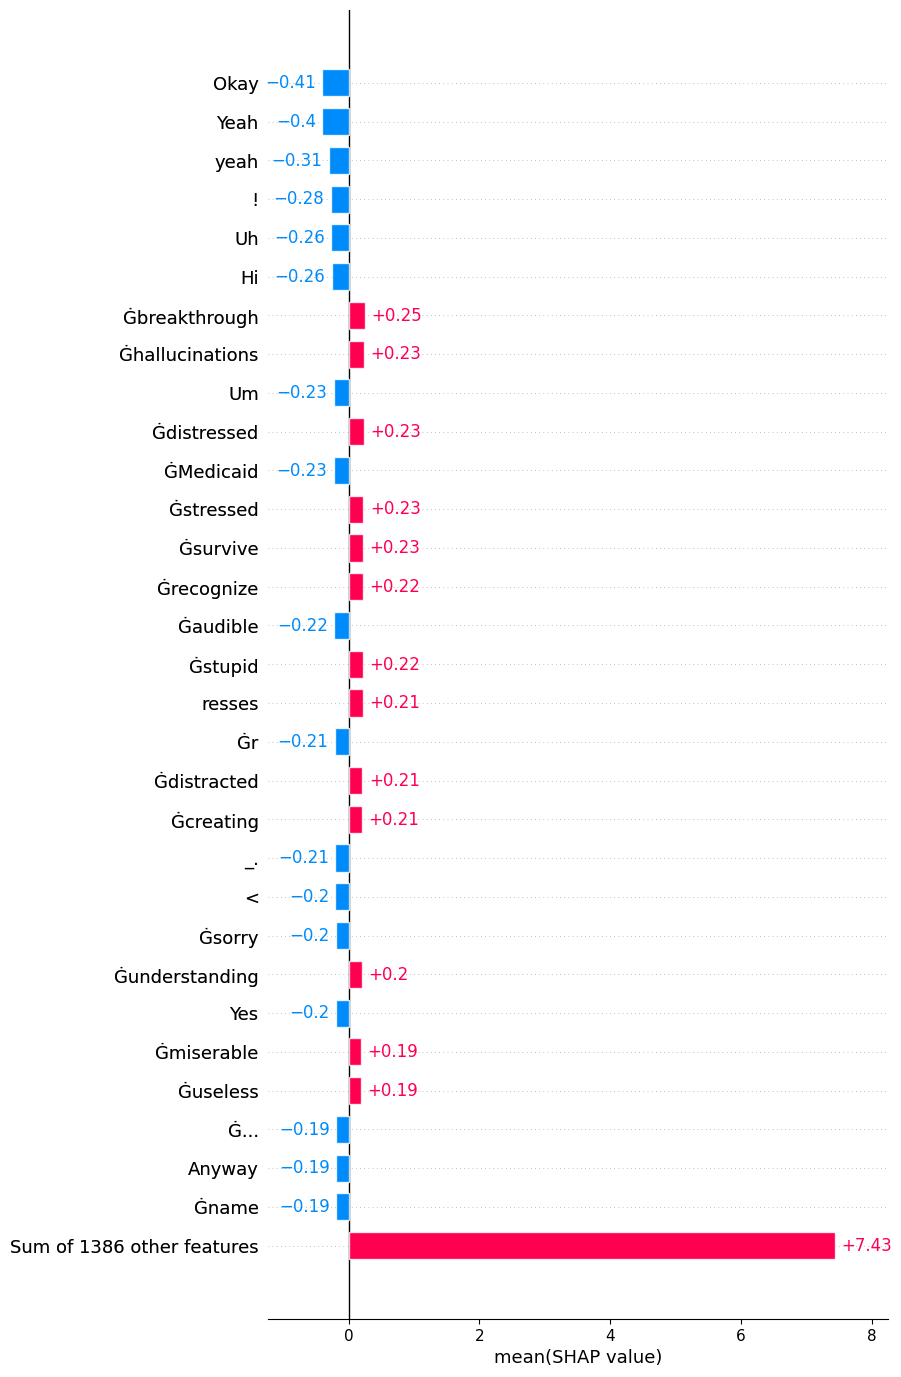

In [58]:
if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z0[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 0.0), dpi=600, bbox_inches='tight')
else:
    shap.plots.bar(shap_z0[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))


plt.close()

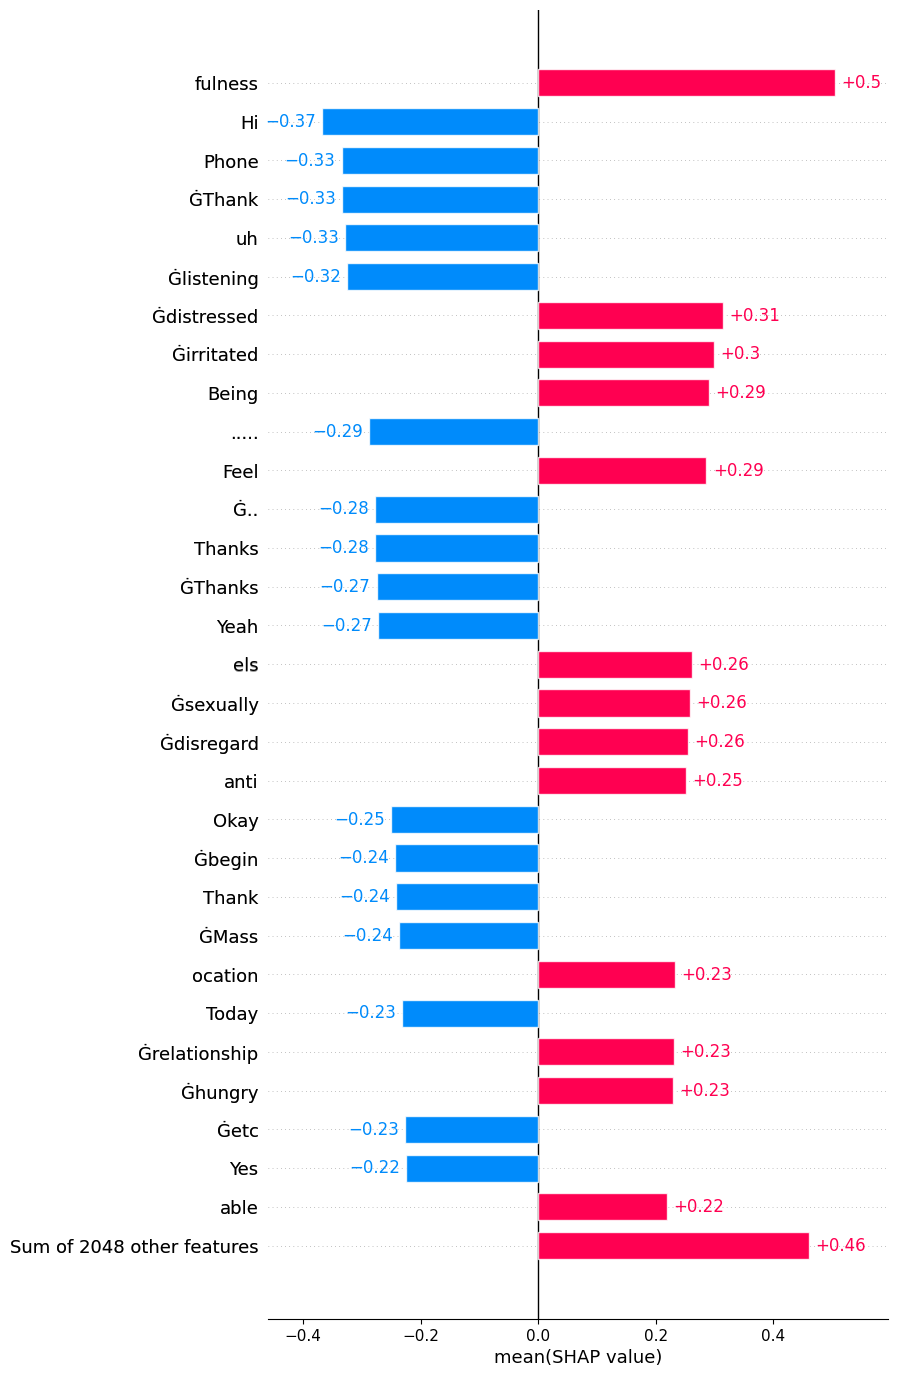

In [59]:
if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 0.0), dpi=600, bbox_inches='tight')

else:
    shap.plots.bar(shap_z1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

plt.close()

In [49]:
outname

'../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png'

### 1.0-1.0

In [ ]:
shap_z0.values.shape

In [ ]:
shap_z0_l2_1.values.shape

In [22]:
with open("../output/TaskVectorFigs/SHAP_CD/roberta_full_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_full_l2_1 = pickle.load(f)

In [23]:
with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z0_l2_1 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z1_l2_1 = pickle.load(f)

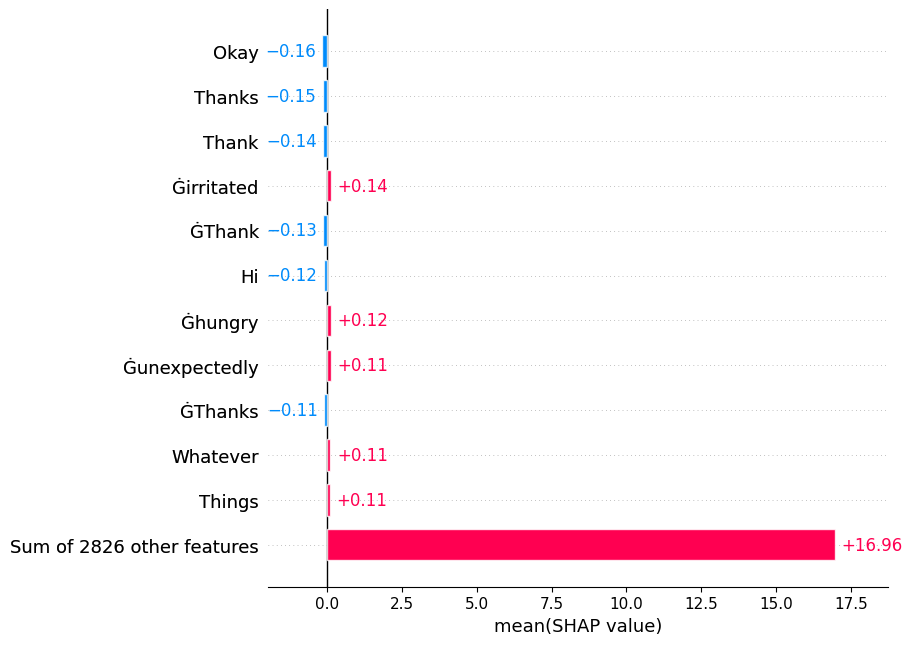

In [24]:
shap.plots.bar(shap_full_l2_1[:,:,"Positive"].mean(0), max_display=12)

In [32]:
savefig=True

In [35]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

<Axes: xlabel='mean(SHAP value)'>

In [36]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

<Axes: xlabel='mean(SHAP value)'>

### 1.0-1.4

In [ ]:
shap_z0.values.shape

In [ ]:
shap_z0_l2_1.values.shape

In [6]:
with open("../output/TaskVectorFigs/SHAP_CD/roberta_full_lambda1_1.0_lambda2_1.4.pkl", "rb") as f:
    shap_full_l2_1 = pickle.load(f)

In [16]:
with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_1.4.pkl", "rb") as f:
    shap_z0_l2_1 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_CD/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_1.4.pkl", "rb") as f:
    shap_z1_l2_1 = pickle.load(f)

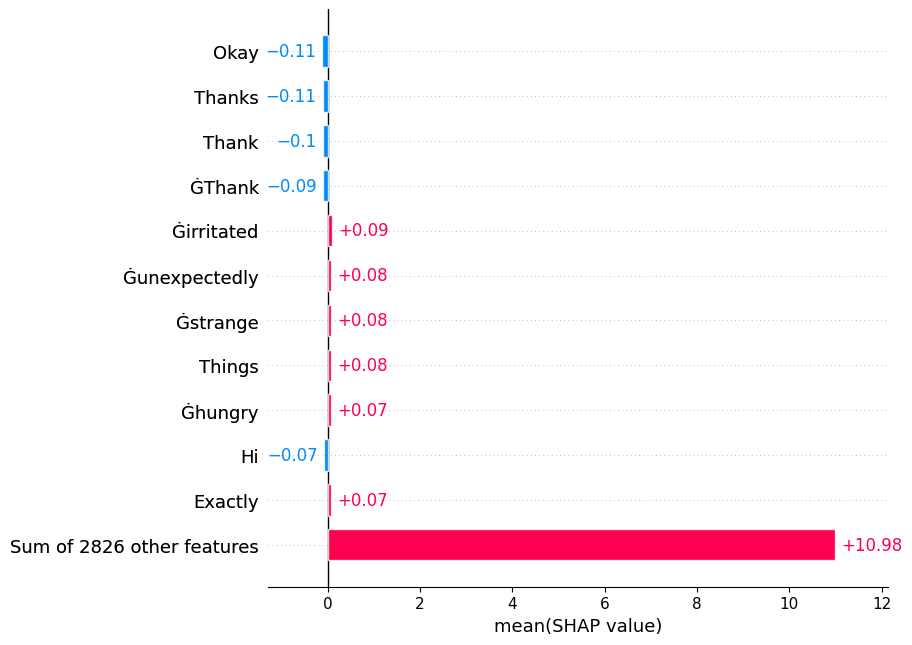

In [32]:
shap.plots.bar(shap_full_l2_1[:,:,"Positive"].mean(0), max_display=12)

In [18]:
savefig=False

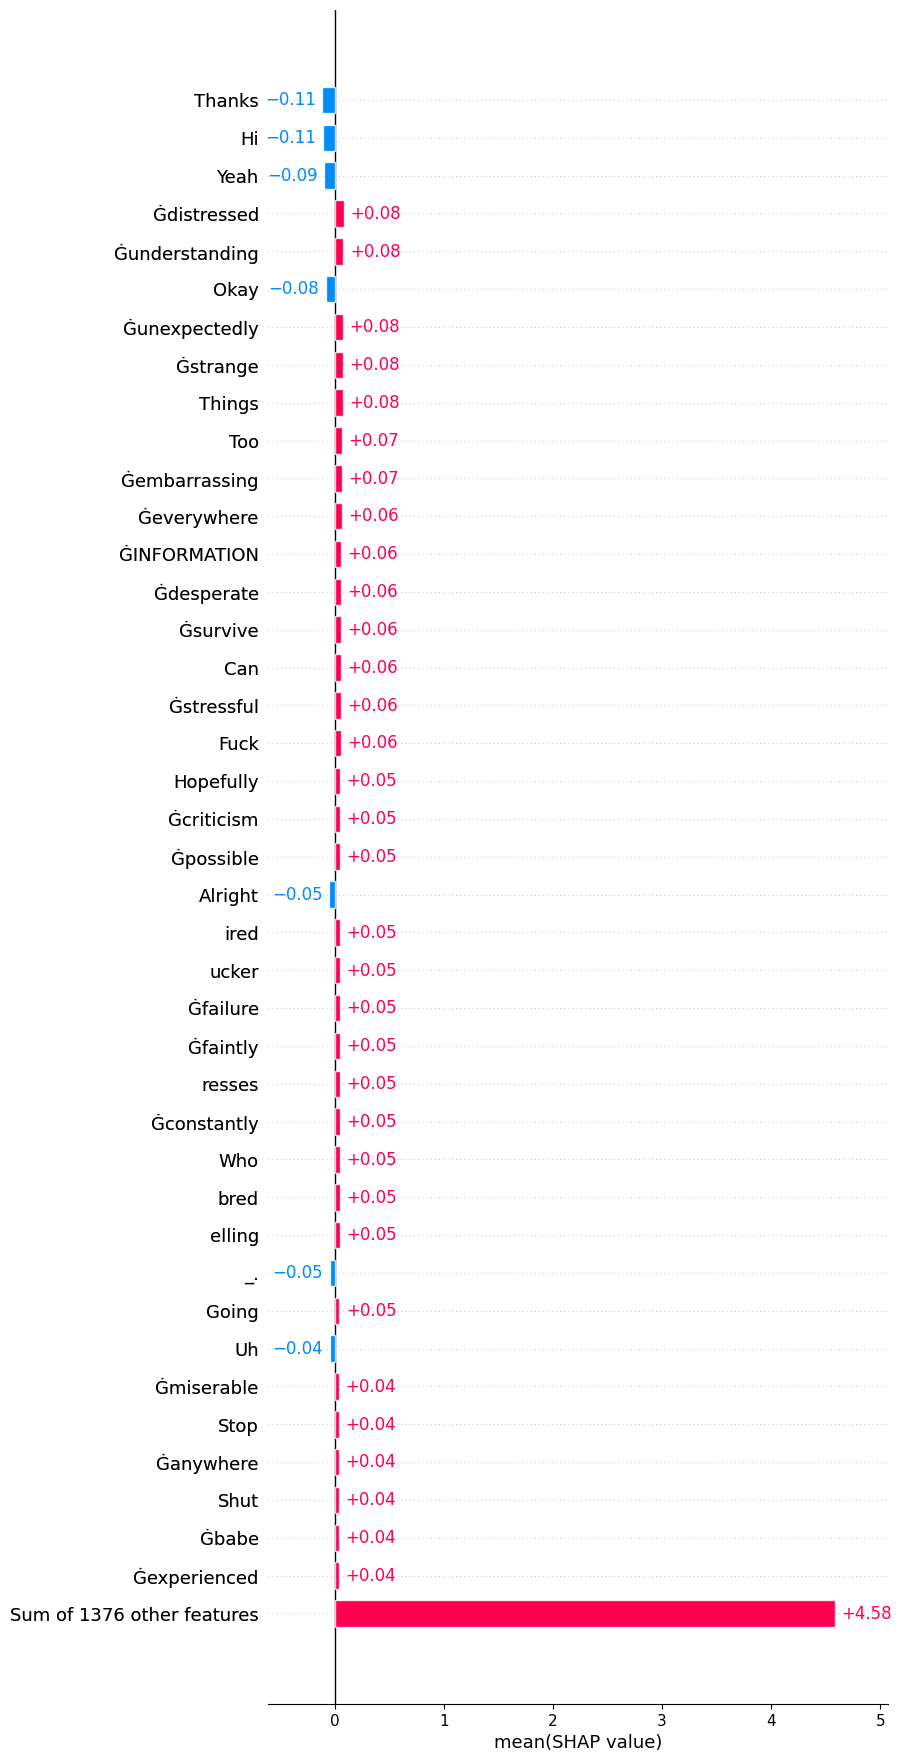

In [22]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 1.4), dpi=600, bbox_inches='tight')

    plt.close()
else:
    shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=41, ax=ax if savefig else None, show=(not savefig))

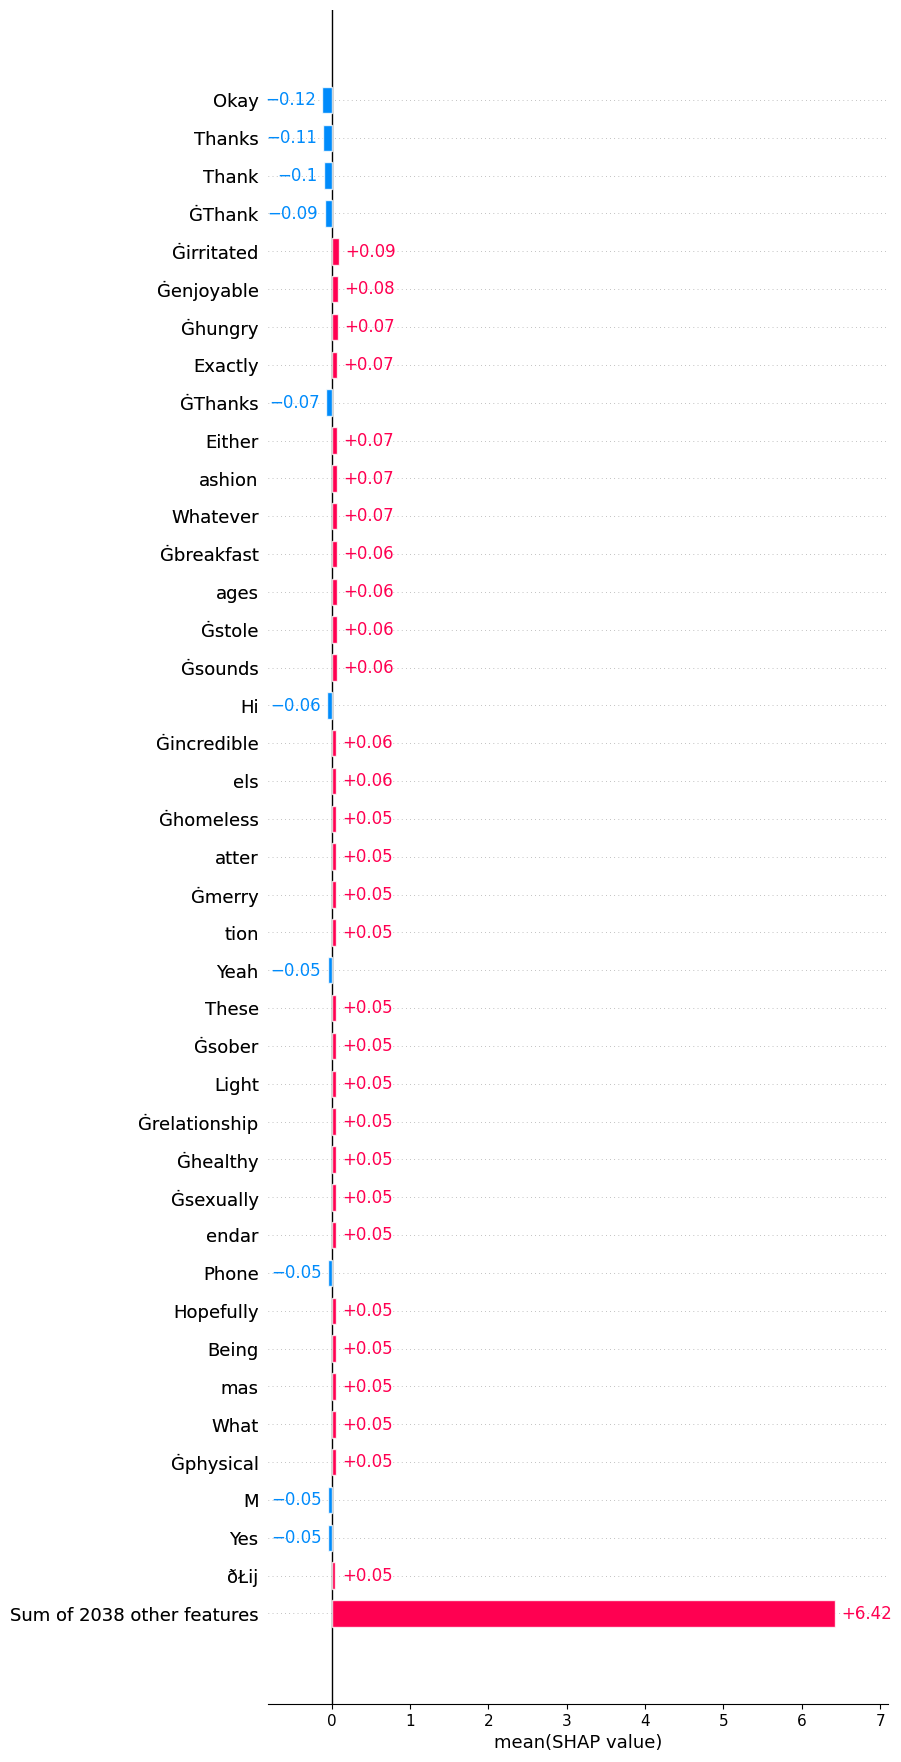

In [21]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 1.4), dpi=600, bbox_inches='tight')
    plt.close()
else:

    shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=41, ax=ax if savefig else None, show=(not savefig))

### Reverse 1.0-0.0 and 1.0-1.0

In [17]:
with open("../output/TaskVectorFigs/SHAP_CD/Reverse-roberta_full_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_full_l2_1 = pickle.load(f)

In [18]:
with open(f"../output/TaskVectorFigs/SHAP_CD/Reverse-roberta_part_{z_Categories[0]}_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_z0_l2_1 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_CD/Reverse-roberta_part_{z_Categories[1]}_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_z1_l2_1 = pickle.load(f)

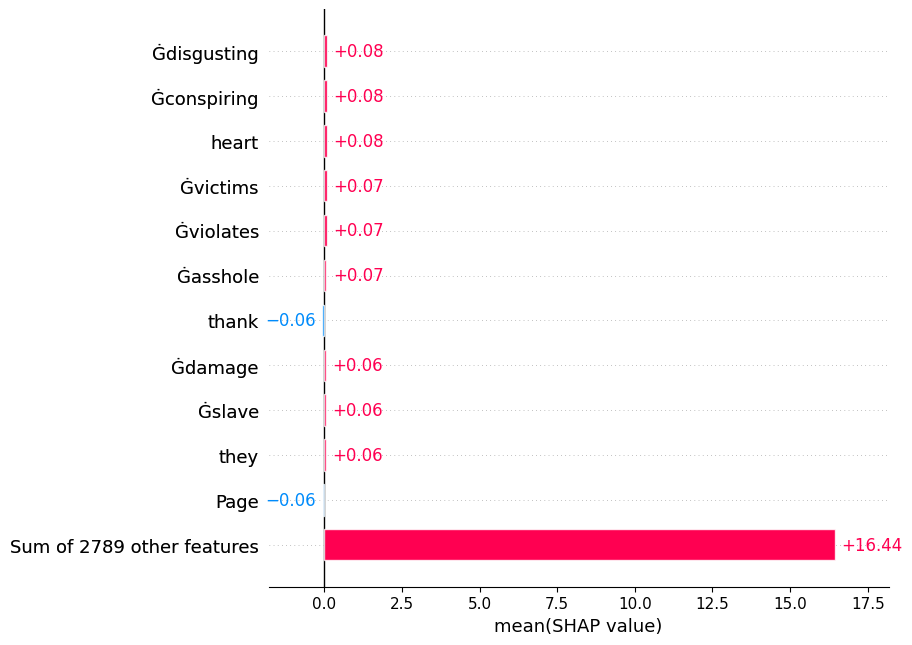

In [19]:
shap.plots.bar(shap_full_l2_1[:,:,"Positive"].mean(0), max_display=12)

In [20]:
savefig=False

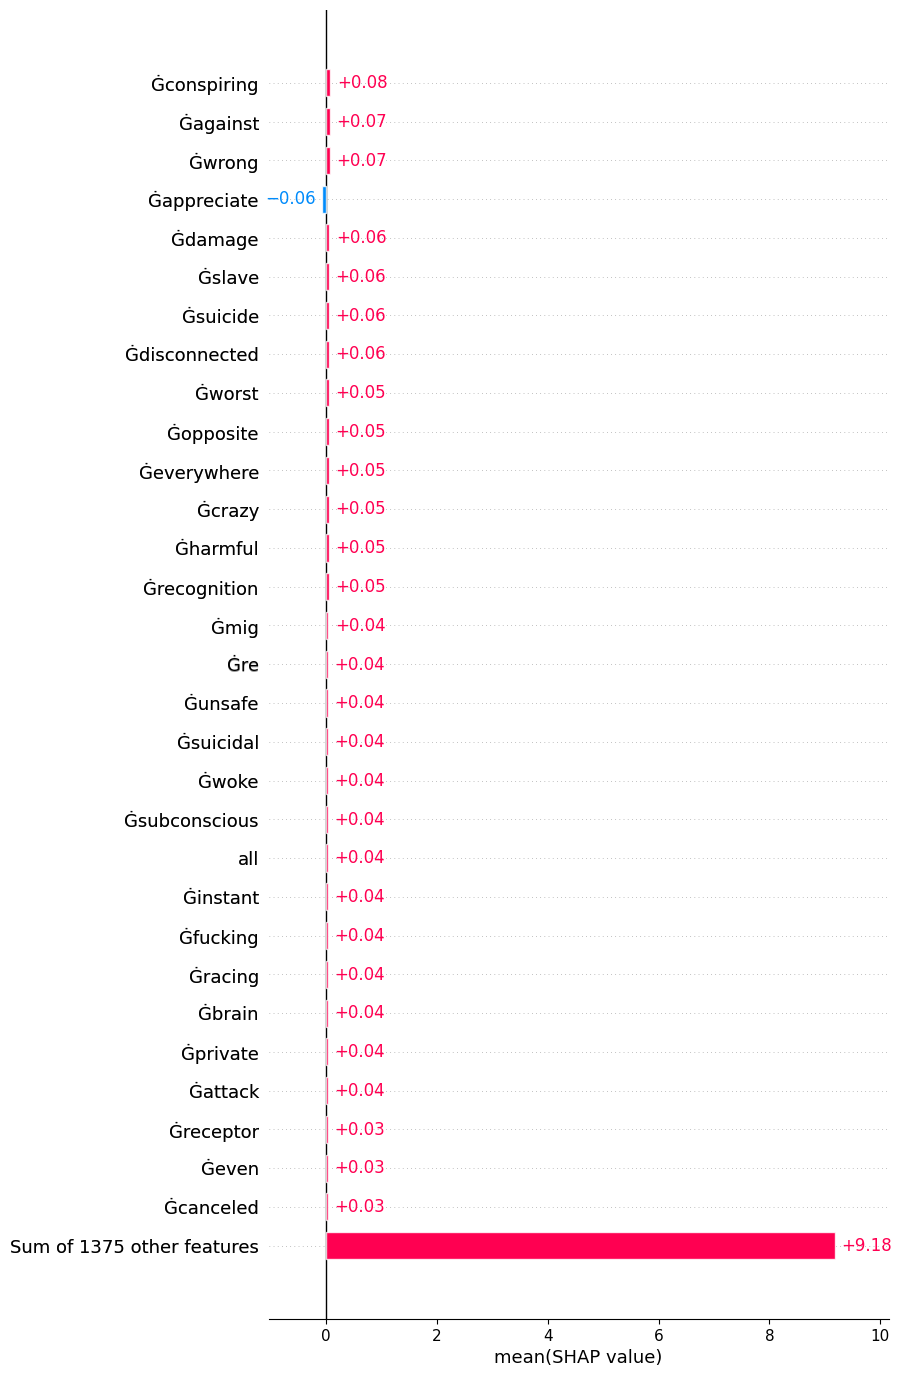

In [21]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 1.4), dpi=600, bbox_inches='tight')

    plt.close()
else:
    shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

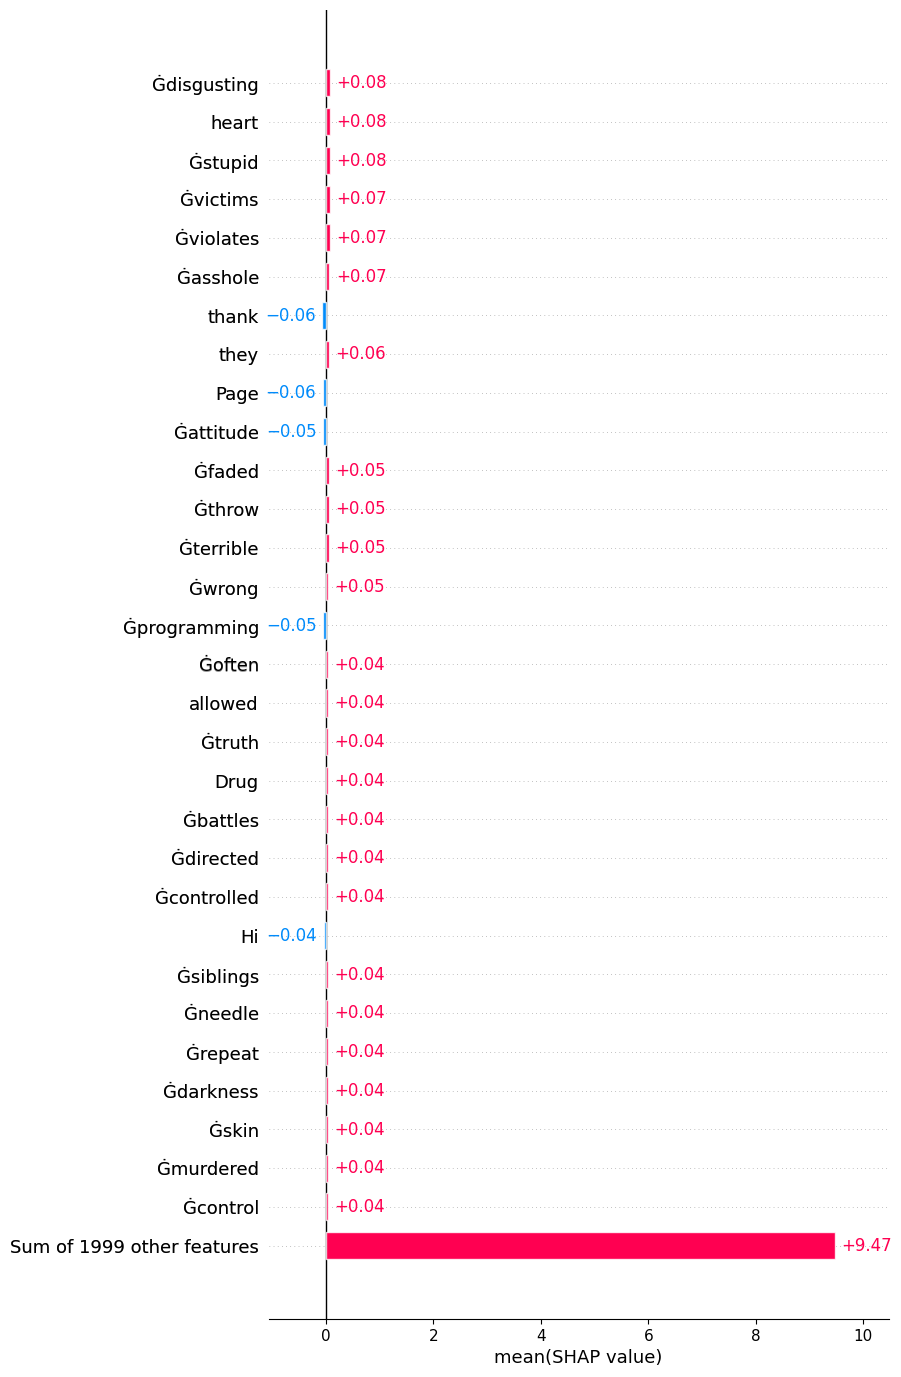

In [22]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=11, ax=ax if savefig else None, show=(not savefig))
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 1.4), dpi=600, bbox_inches='tight')
    plt.close()
else:

    shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

### Predicting Provenance - 566 S

In [12]:
with open("../output/TaskVectorFigs/SHAP_CD/roberta_full_Main.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [13]:
# outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

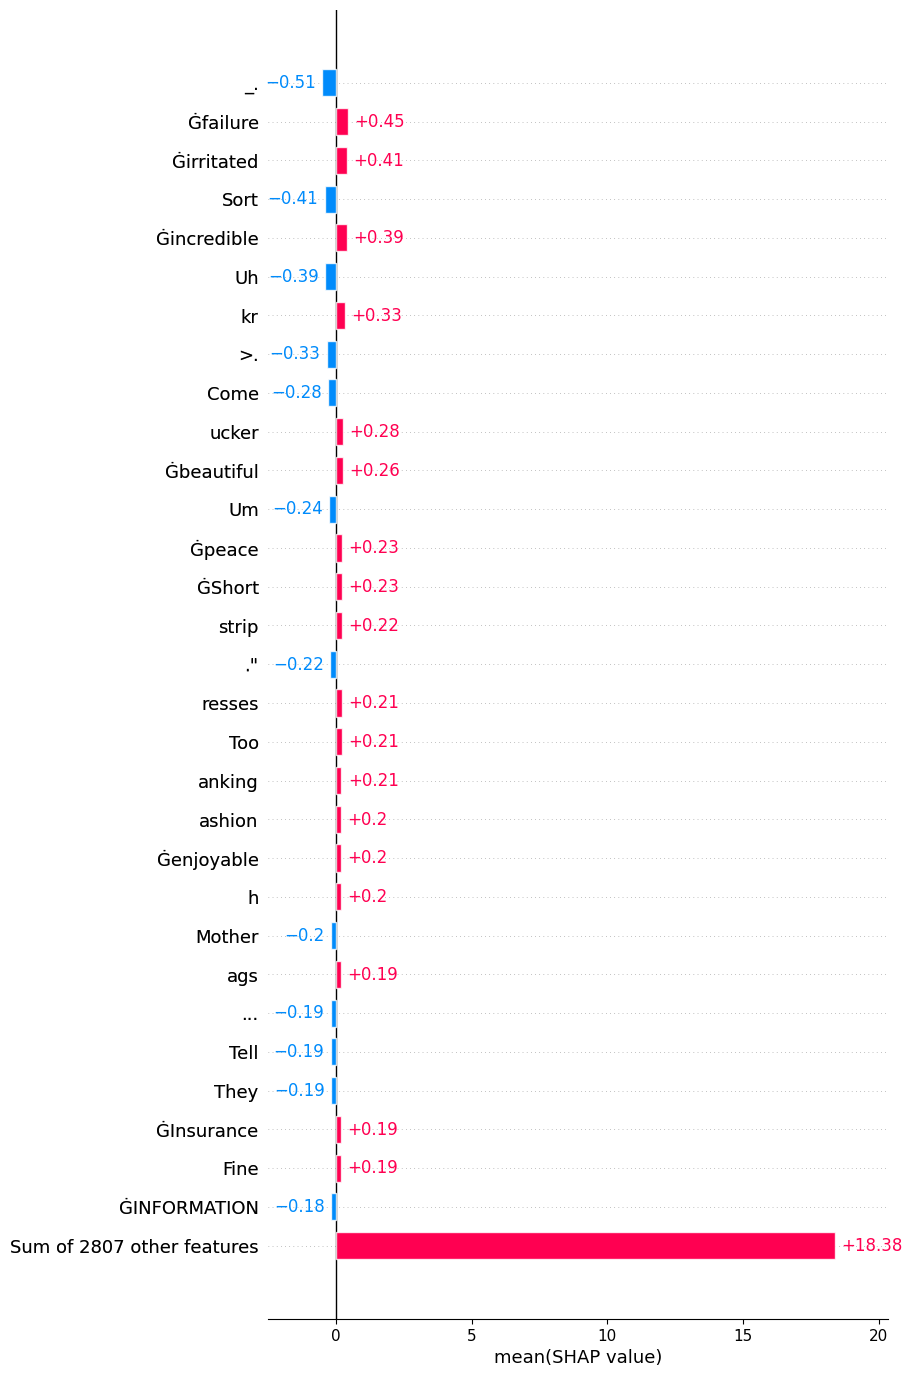

In [14]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=31)

## Readin and Explain: HateSpeech

In [9]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [10]:
import matplotlib.pyplot as plt

### 1.0-0.0

In [11]:
with open("../output/TaskVectorFigs/SHAP_HateSpeech/roberta_full_lambda1_1.0_lambda2_0.0.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [12]:
with open(f"../output/TaskVectorFigs/SHAP_HateSpeech/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z0 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_HateSpeech/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z1 = pickle.load(f)

In [13]:
outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

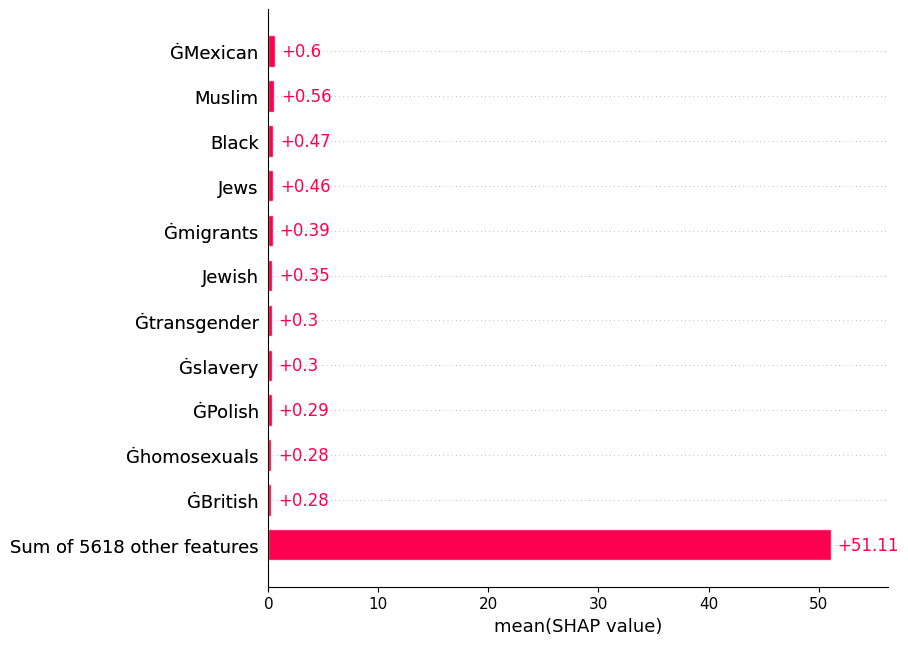

In [23]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=12)

In [14]:
savefig = False

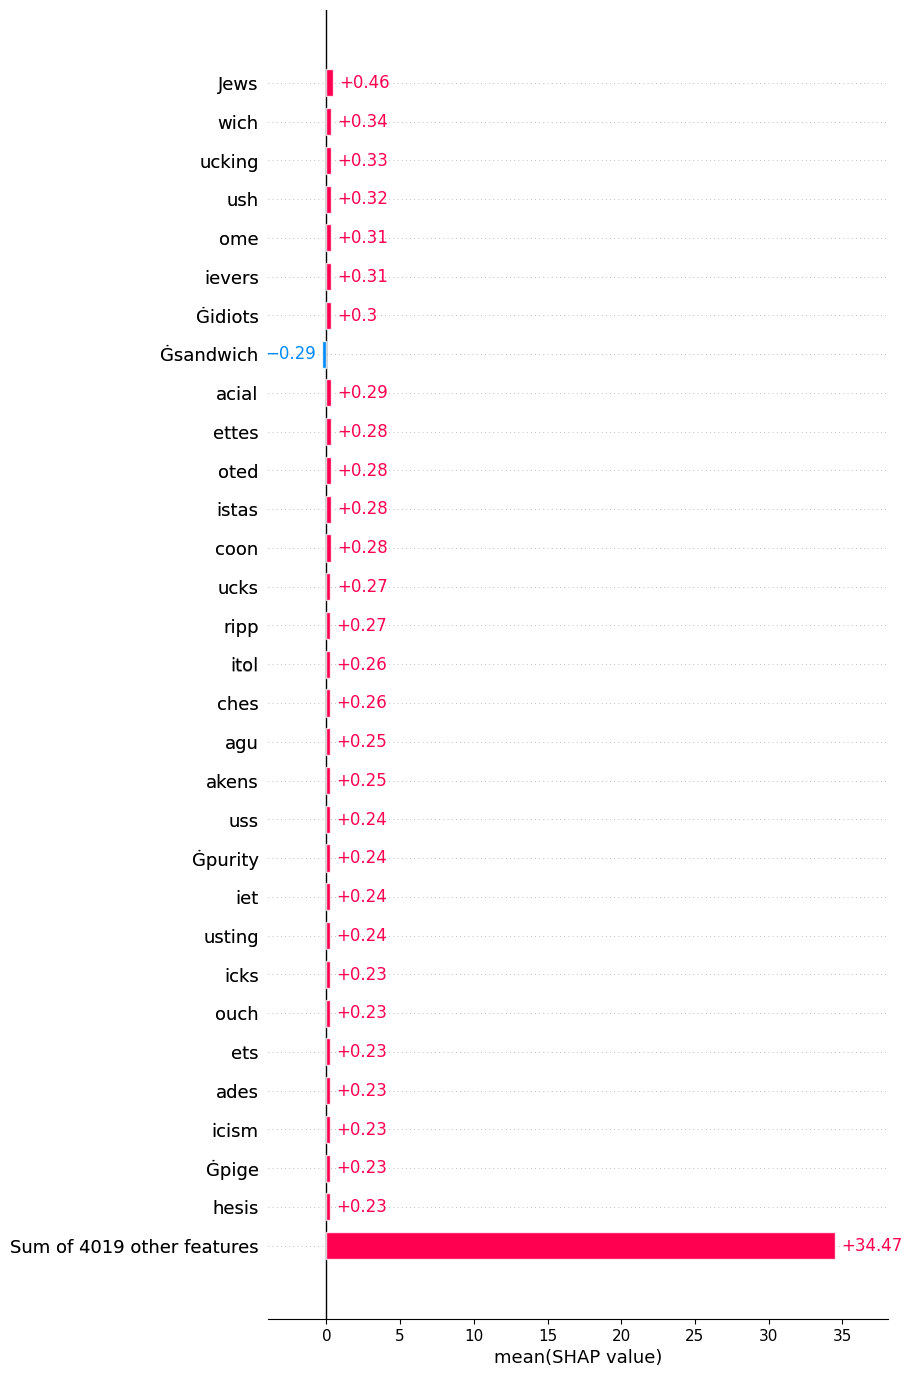

In [15]:
if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 0.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z0[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

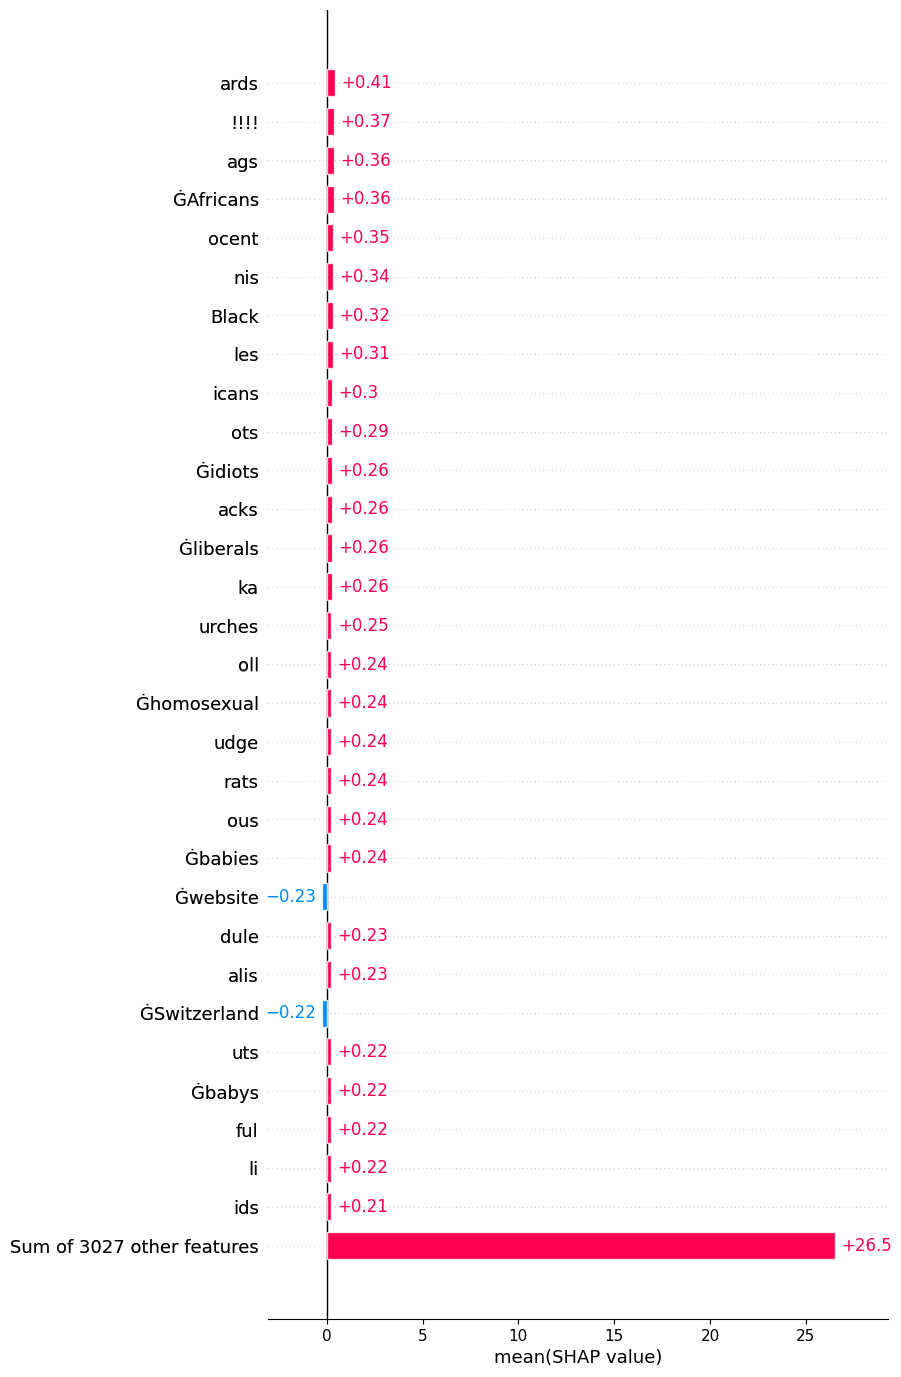

In [16]:
if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 0.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

### 1.0-1.0

In [27]:
shap_z0.values.shape

(500,)

In [17]:
with open("../output/TaskVectorFigs/SHAP_HateSpeech/roberta_full_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_full_l2_1 = pickle.load(f)

In [18]:
with open(f"../output/TaskVectorFigs/SHAP_HateSpeech/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z0_l2_1 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_HateSpeech/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z1_l2_1 = pickle.load(f)

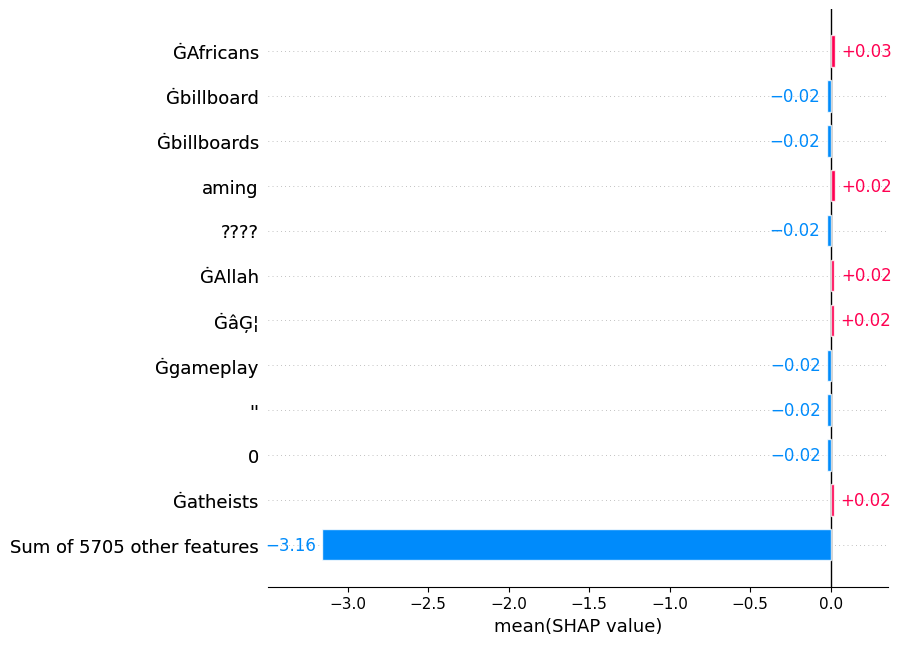

In [30]:
shap.plots.bar(shap_full_l2_1[:,:,"Positive"].mean(0), max_display=12)

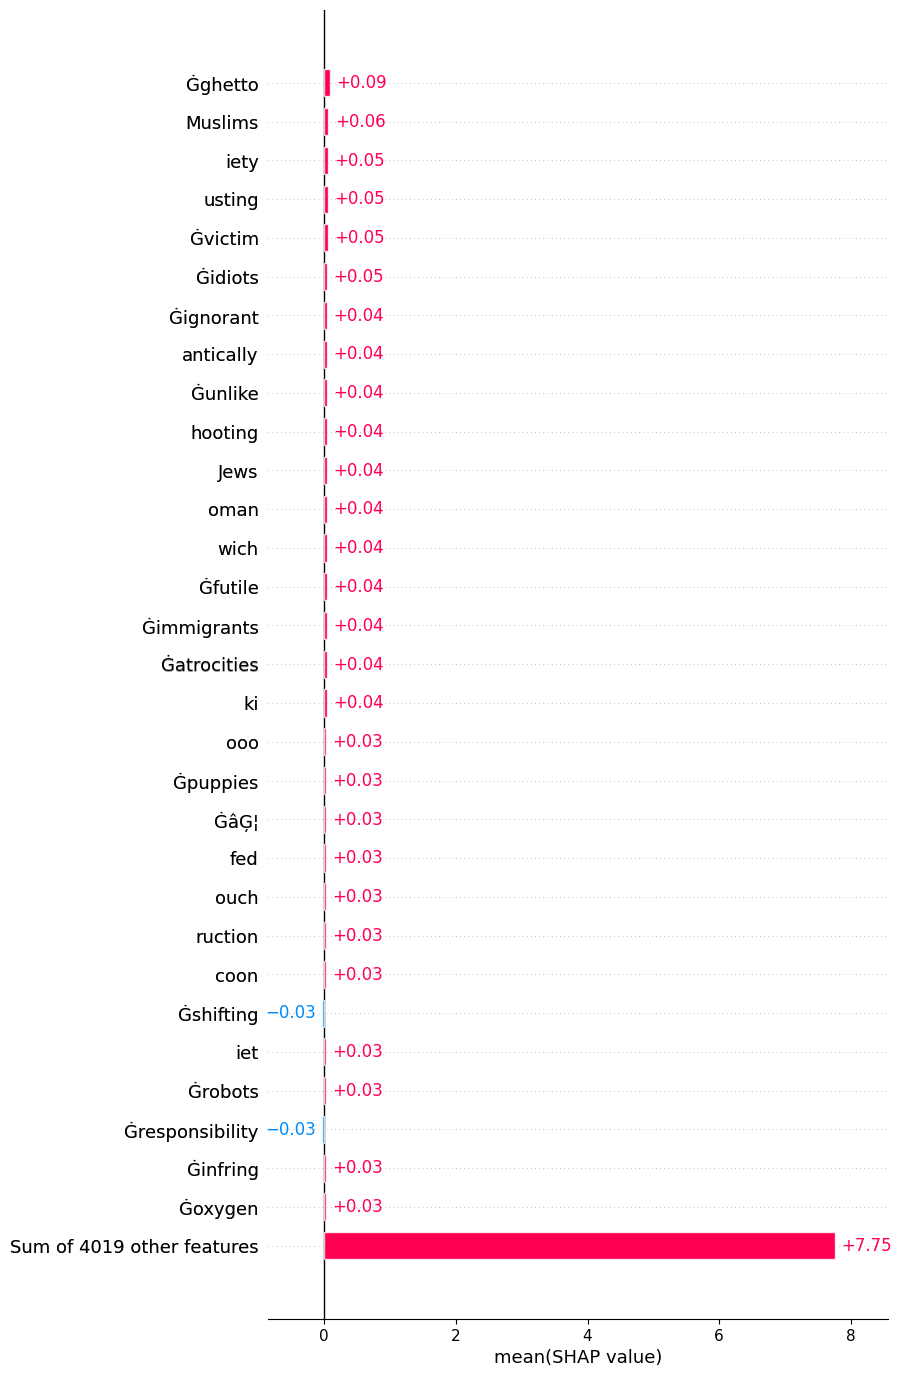

In [19]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

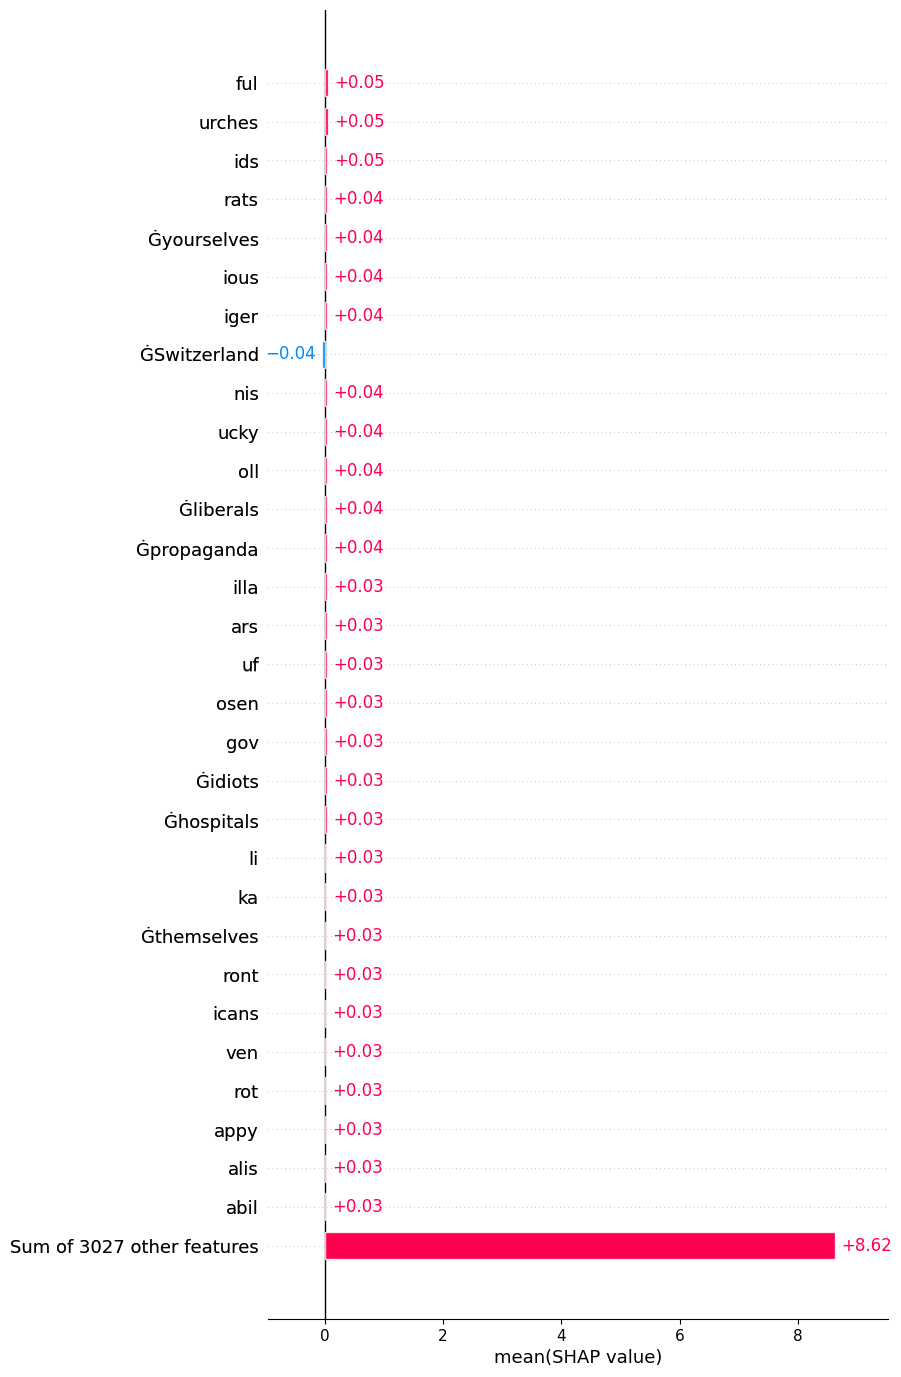

In [20]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

### Predicting Provenance - 6621 RS

In [17]:
with open("../output/TaskVectorFigs/SHAP_HateSpeech/roberta_full_Main.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [18]:
# outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

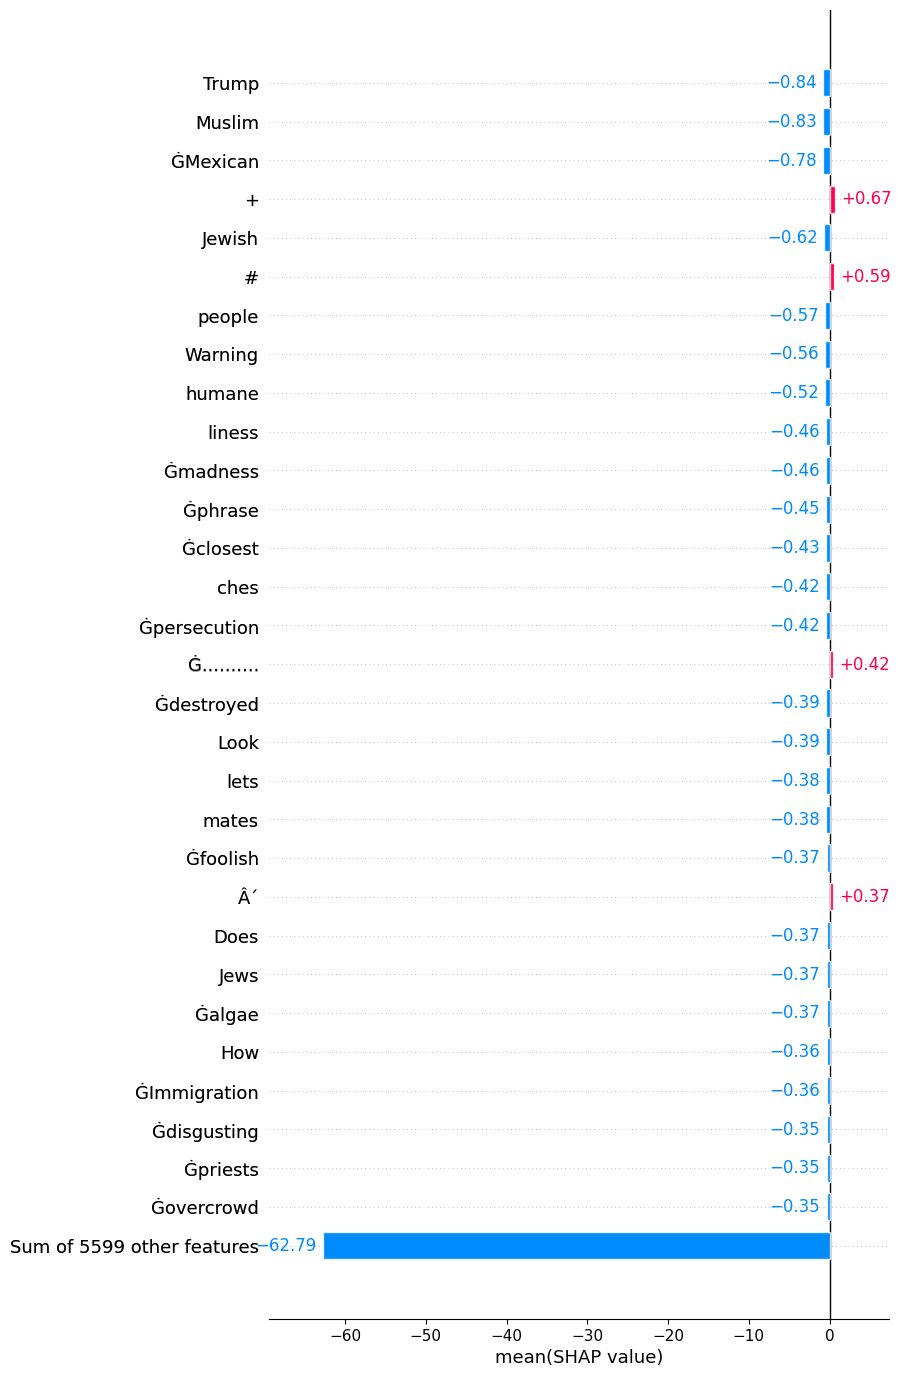

In [21]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=31)

## Readin and Explain: SHAC

In [19]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [20]:
import matplotlib.pyplot as plt

### 1.0-0.0

In [21]:
with open("../output/TaskVectorFigs/SHAP_SHAC/roberta_full_lambda1_1.0_lambda2_0.0.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [22]:
with open(f"../output/TaskVectorFigs/SHAP_SHAC/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z0 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_SHAC/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_0.0.pkl", "rb") as f:
    shap_z1 = pickle.load(f)

In [23]:
outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

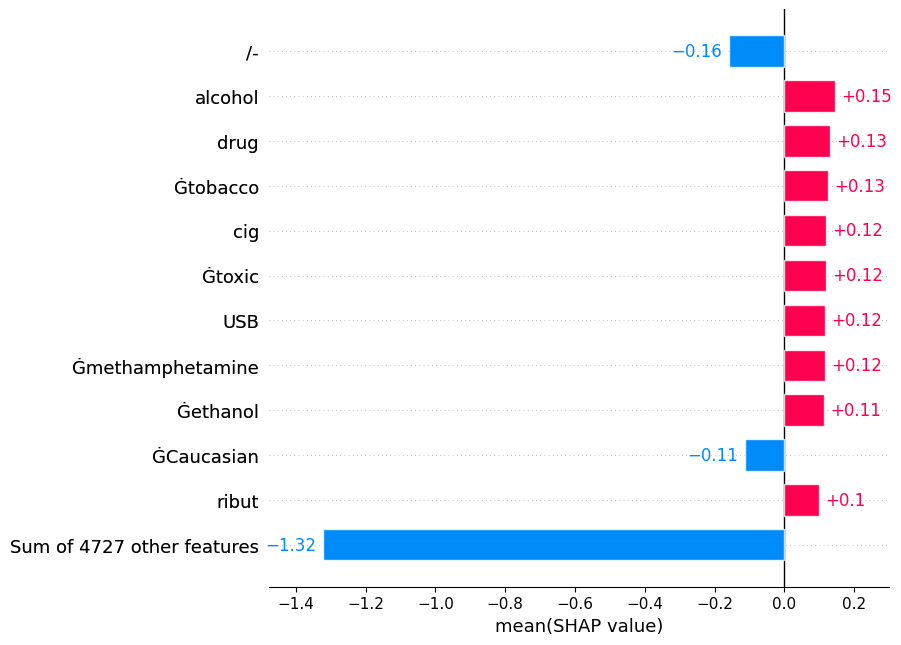

In [25]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=12)

In [24]:
savefig = True

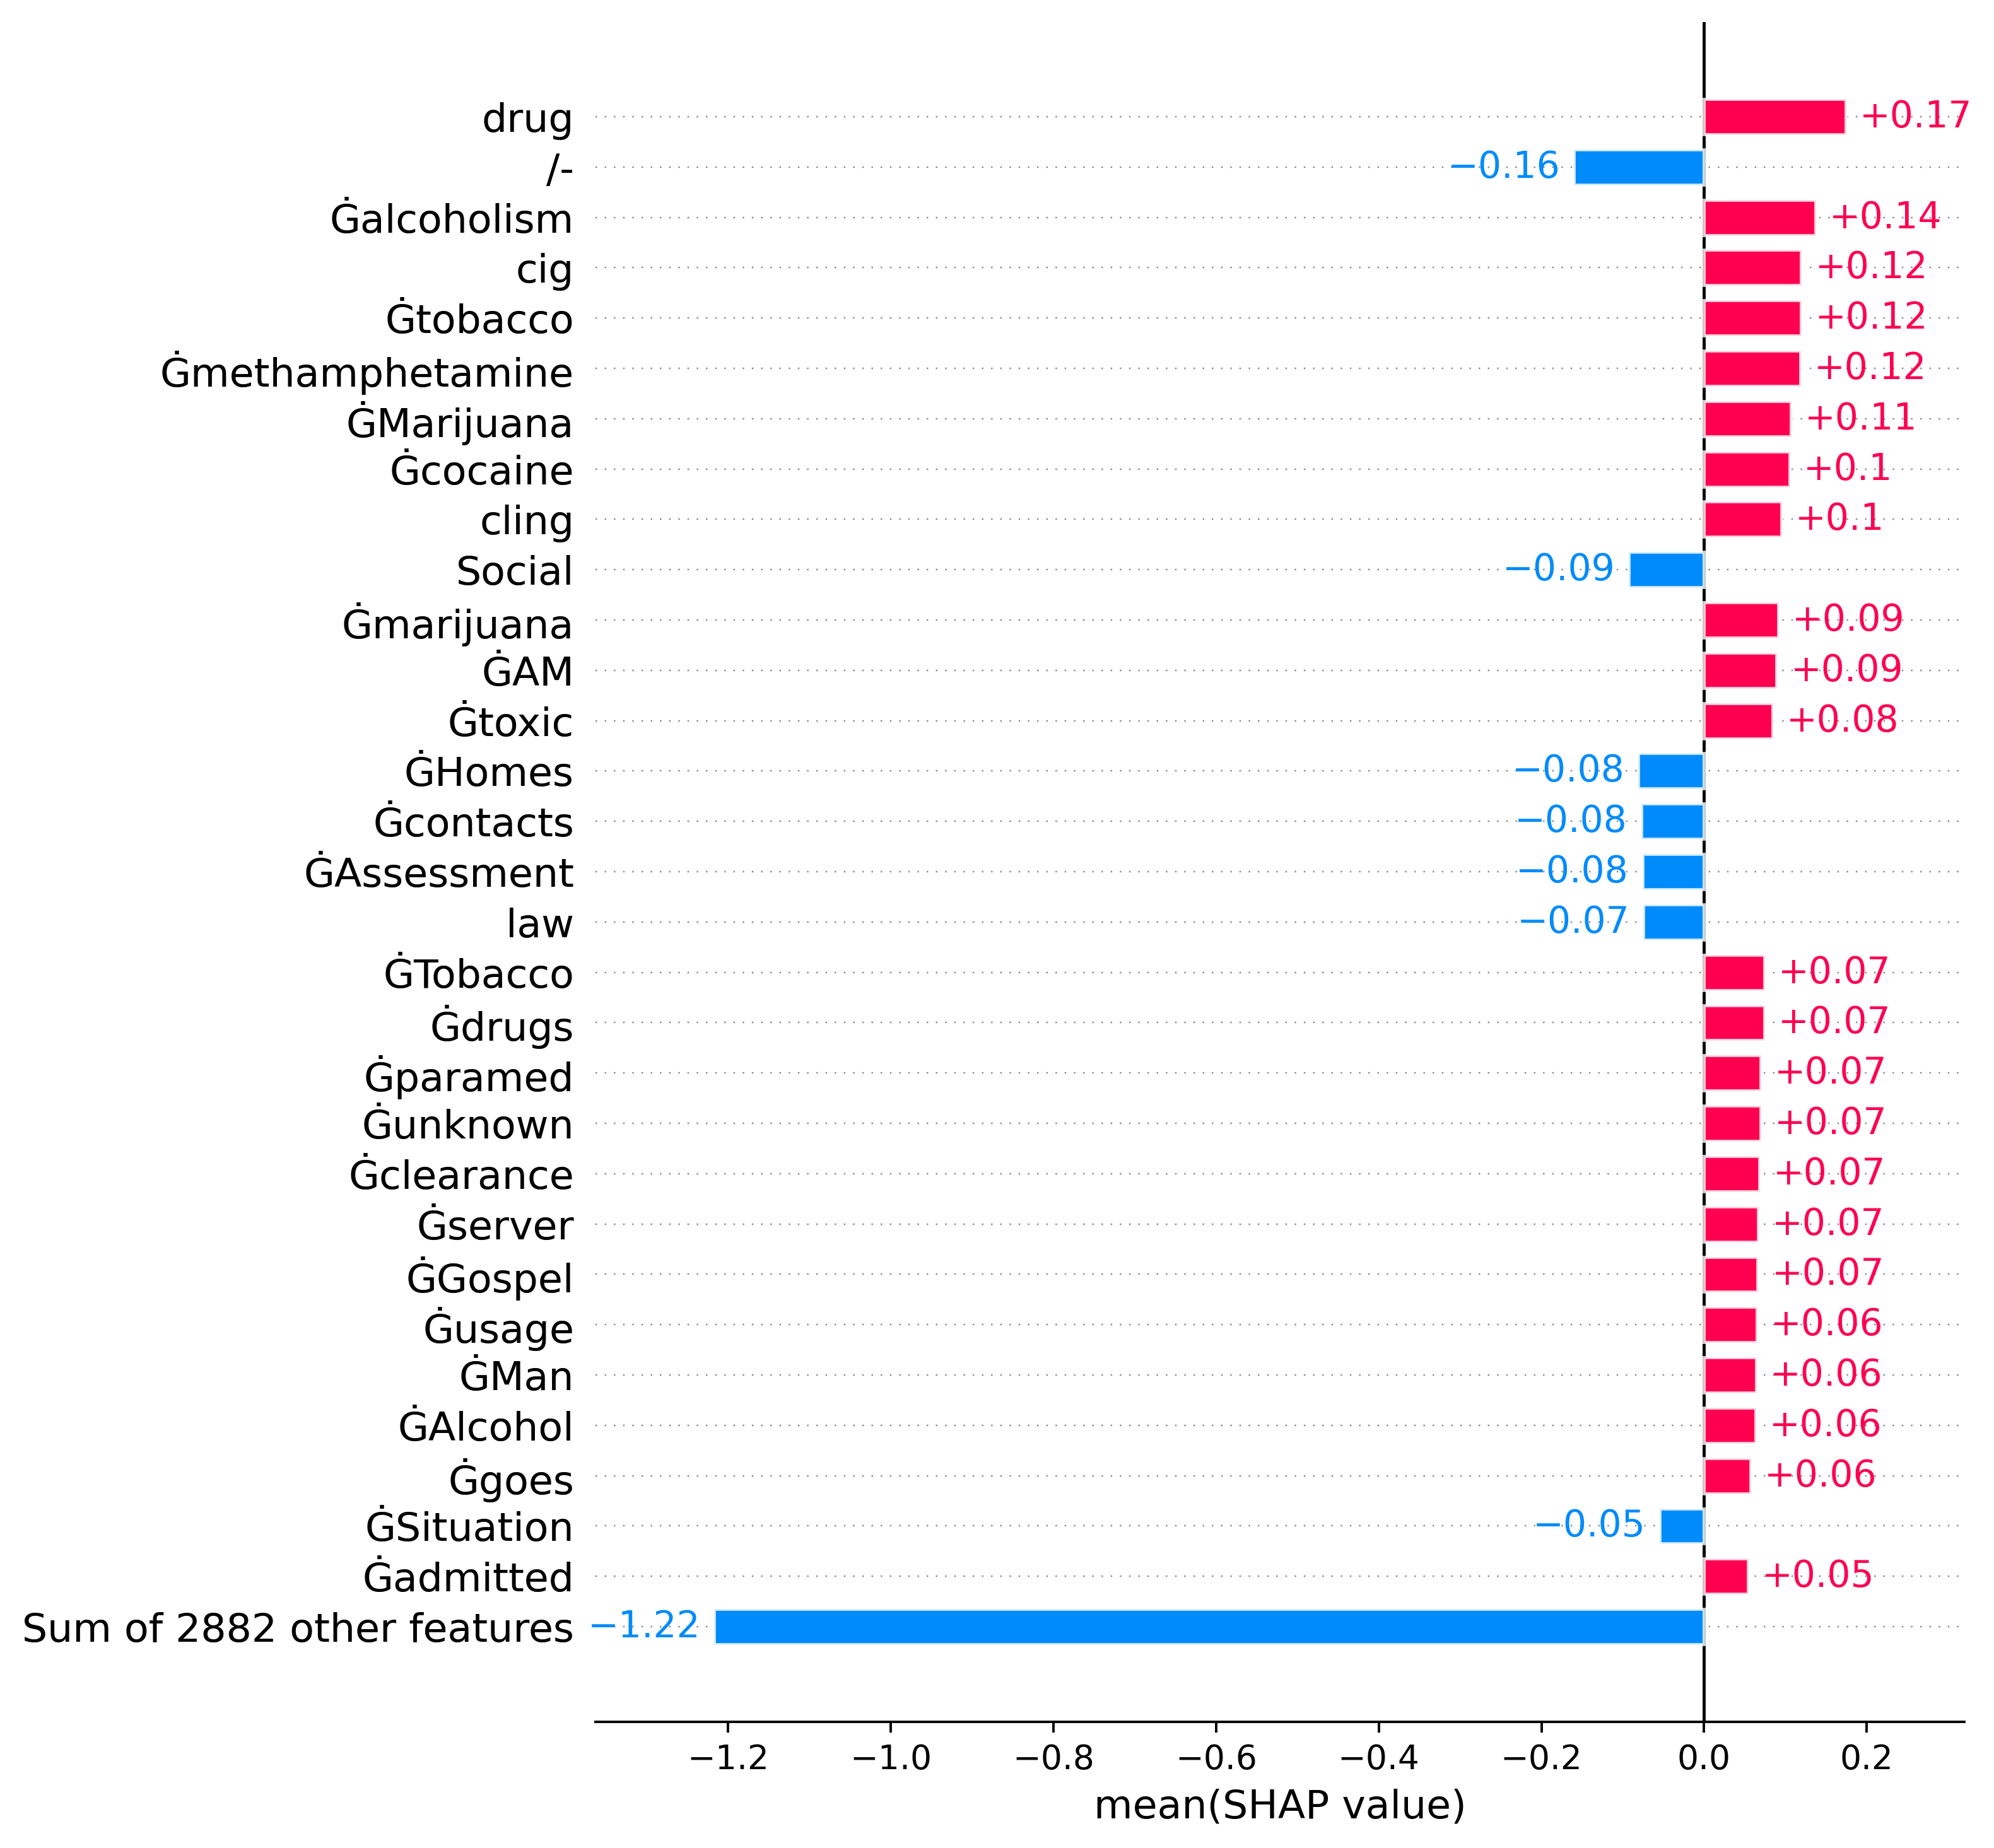

In [36]:



fig, ax = plt.subplots(1,1, figsize=(8,10), dpi=350)

shap.plots.bar(shap_z0[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

plt.savefig(outname.format(dataset_name, "z0", lambda1, 0.0), dpi=600, bbox_inches='tight')
    


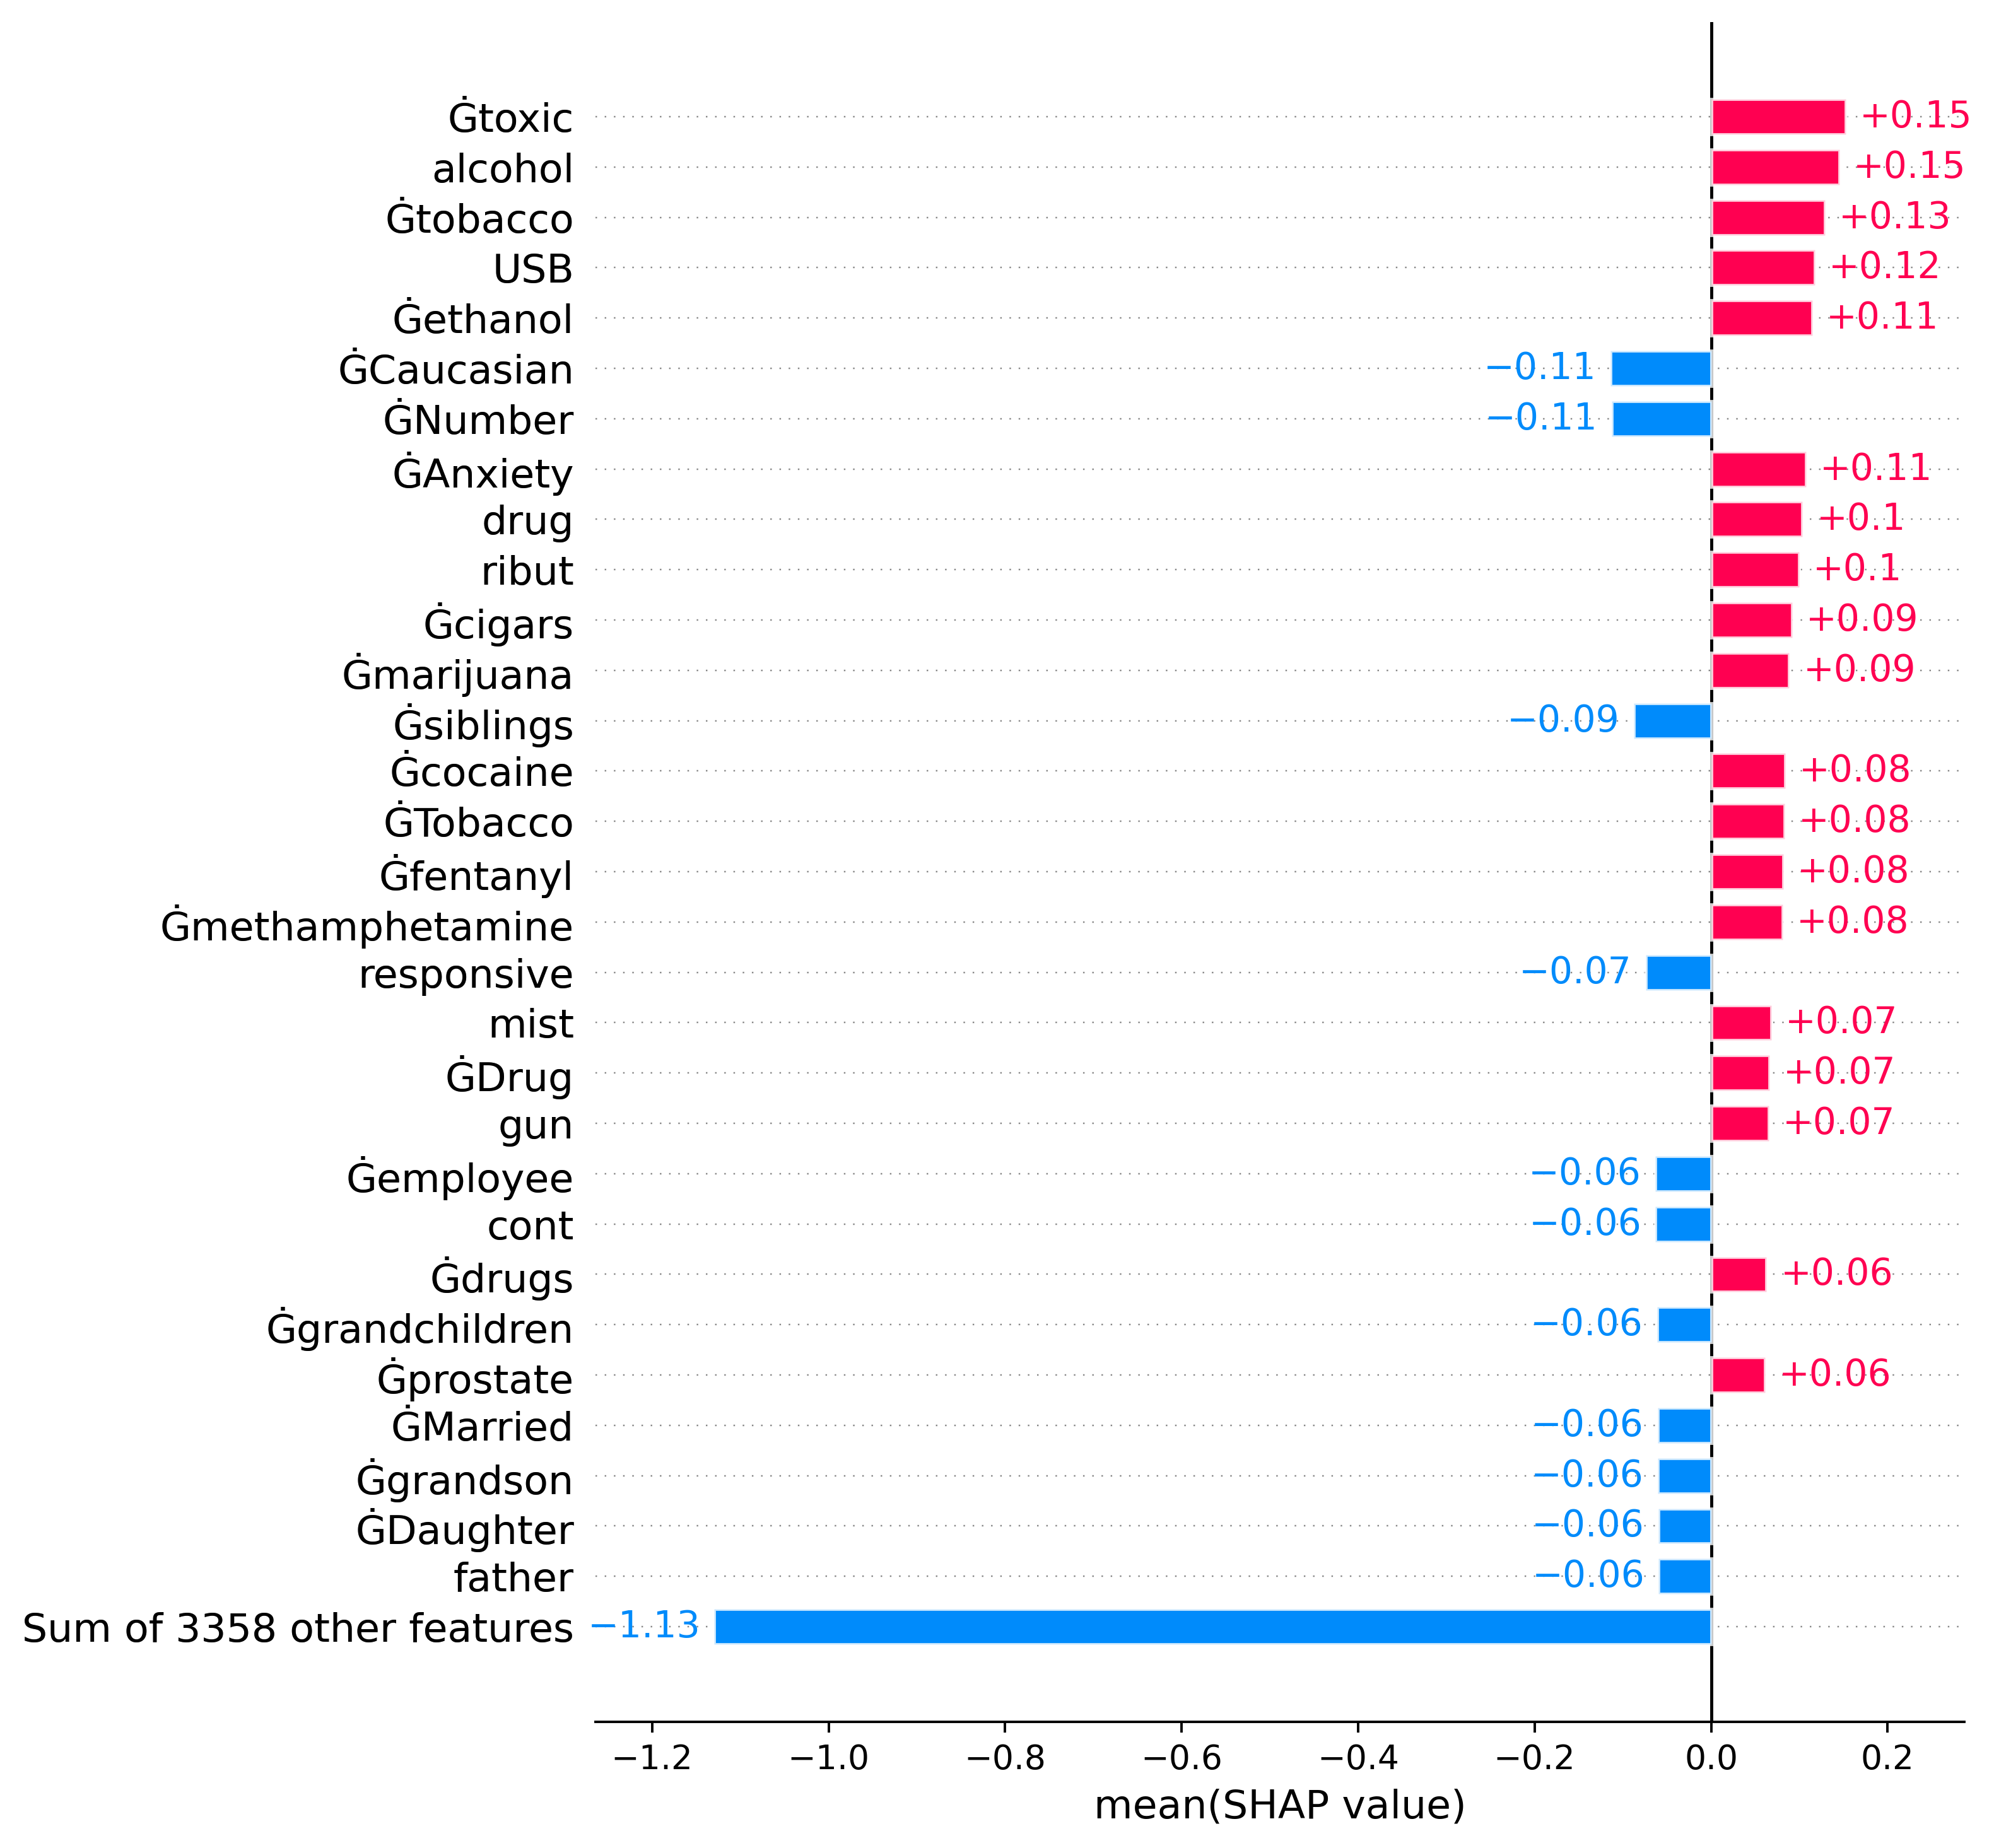

In [37]:
fig, ax = plt.subplots(1,1, figsize=(8,10), dpi=350)
shap.plots.bar(shap_z1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))
plt.savefig(outname.format(dataset_name, "z1", lambda1, 0.0), dpi=600, bbox_inches='tight')



### 1.0-1.0

In [29]:
shap_z0.values.shape

(500,)

In [24]:
with open("../output/TaskVectorFigs/SHAP_SHAC/roberta_full_lambda1_1.0_lambda2_1.0.pkl", "rb") as f:
    shap_full_l2_1 = pickle.load(f)

In [25]:
with open(f"../output/TaskVectorFigs/SHAP_SHAC/roberta_part_{z_Categories[0]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z0_l2_1 = pickle.load(f)

with open(f"../output/TaskVectorFigs/SHAP_SHAC/roberta_part_{z_Categories[1]}_lambda1_{lambda1}_lambda2_1.0.pkl", "rb") as f:
    shap_z1_l2_1 = pickle.load(f)

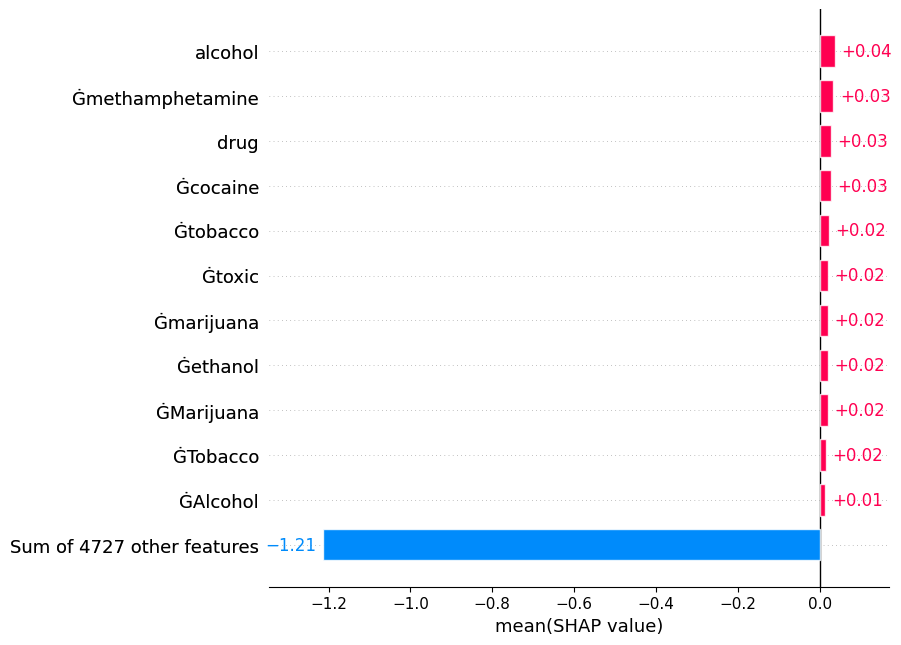

In [34]:
shap.plots.bar(shap_full_l2_1[:,:,"Positive"].mean(0), max_display=12)

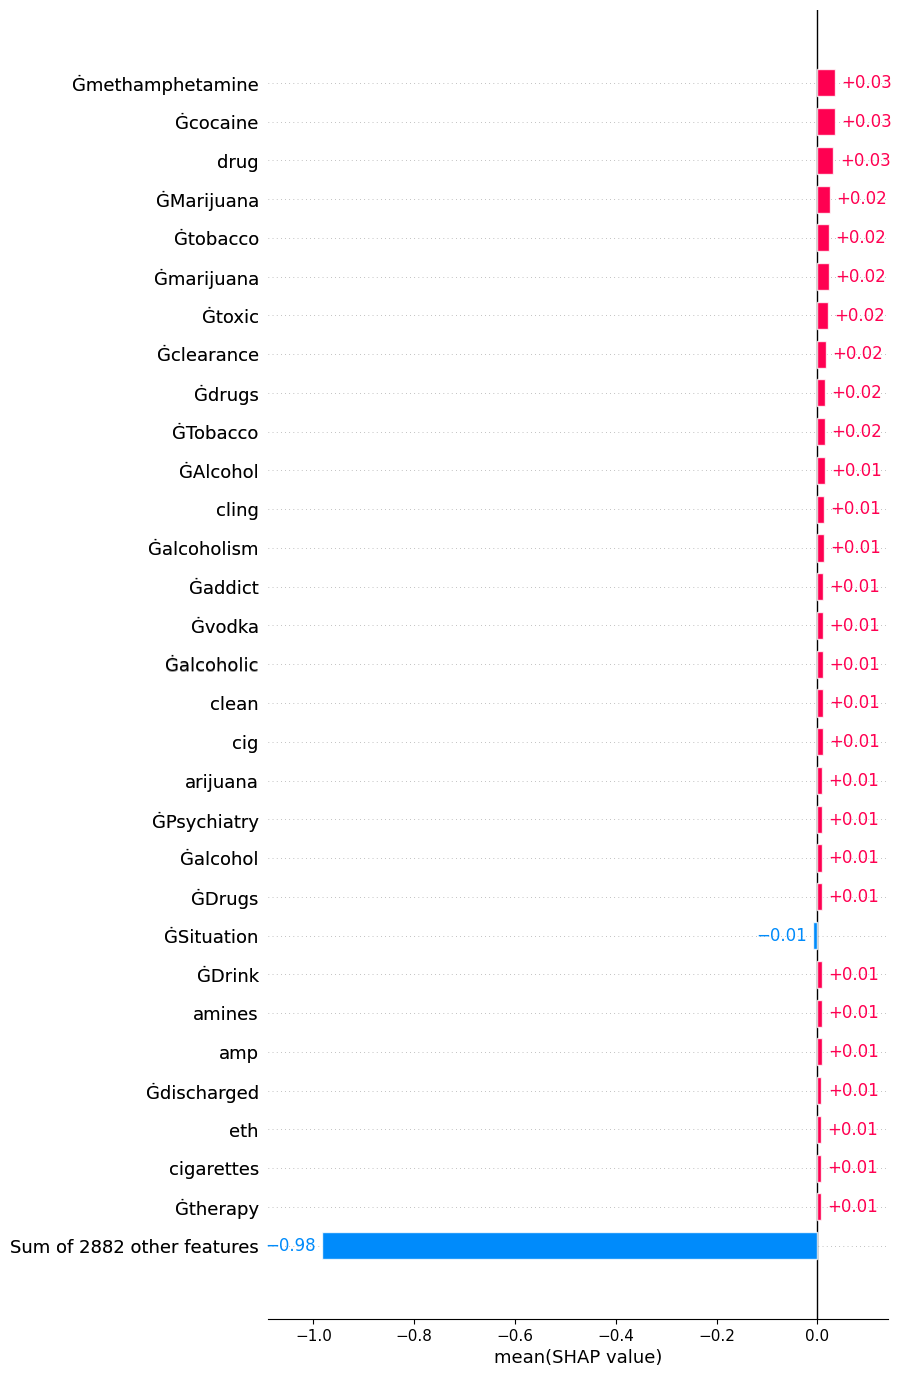

In [35]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z0", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z0_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

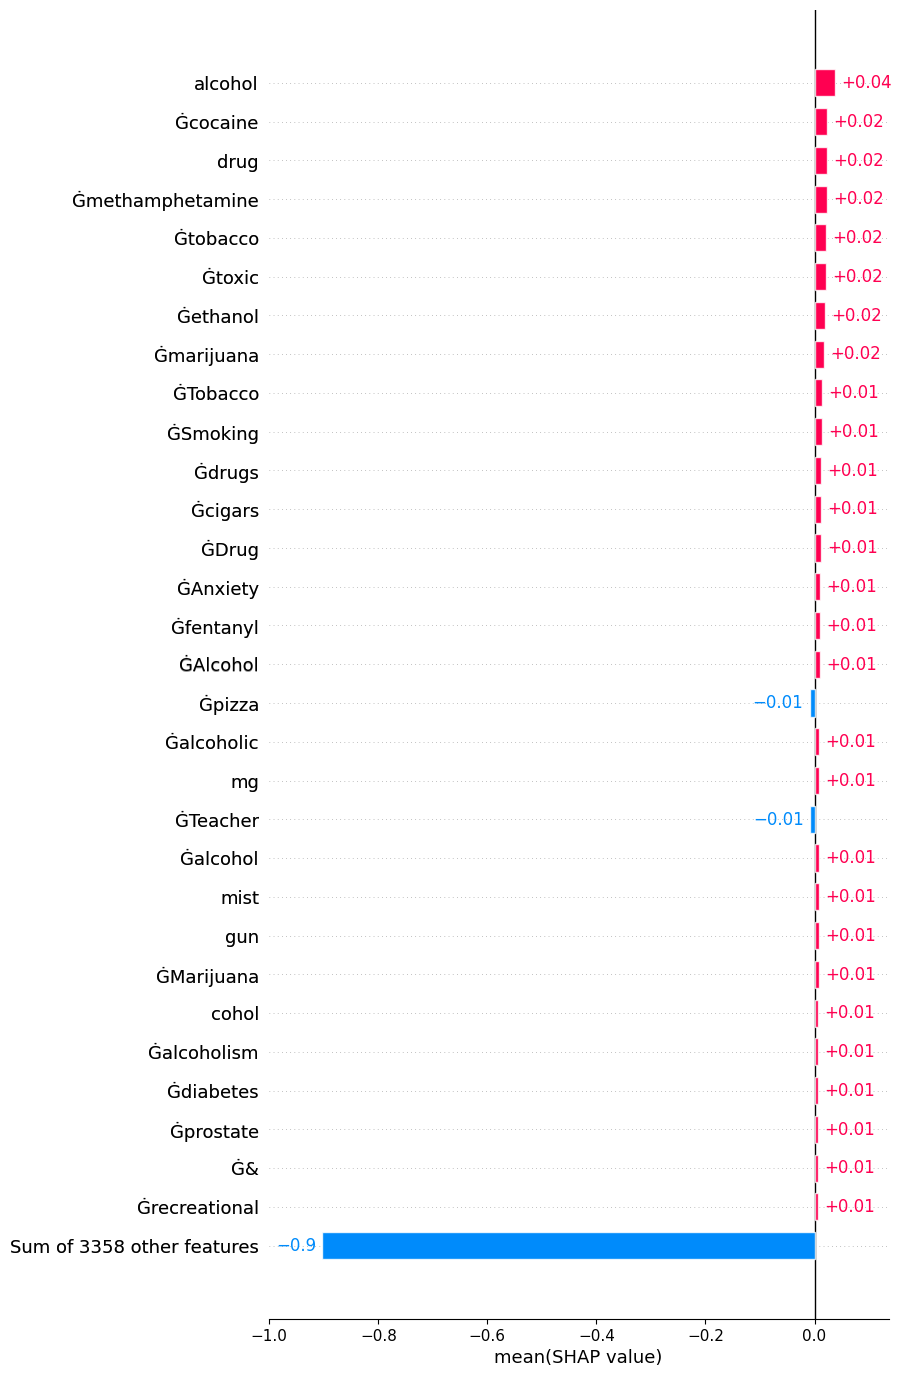

In [36]:

if savefig:
    fig, ax = plt.subplots(1,1, figsize=(8,8), dpi=350)
    plt.savefig(outname.format(dataset_name, "z1", lambda1, 1.0), dpi=600, bbox_inches='tight')

shap.plots.bar(shap_z1_l2_1[:,:,"Positive"].mean(0), max_display=31, ax=ax if savefig else None, show=(not savefig))

### Predicting Provenance - 11063 RS

In [7]:
with open("../output/TaskVectorFigs/SHAP_SHAC/roberta_full_Main.pkl", "rb") as f:
    shap_full = pickle.load(f)

In [8]:
# outname = "../output/TaskVectorFigs/fig_SHAP_{}_z_{}_lambda1_{}_lambda2_{}.png"

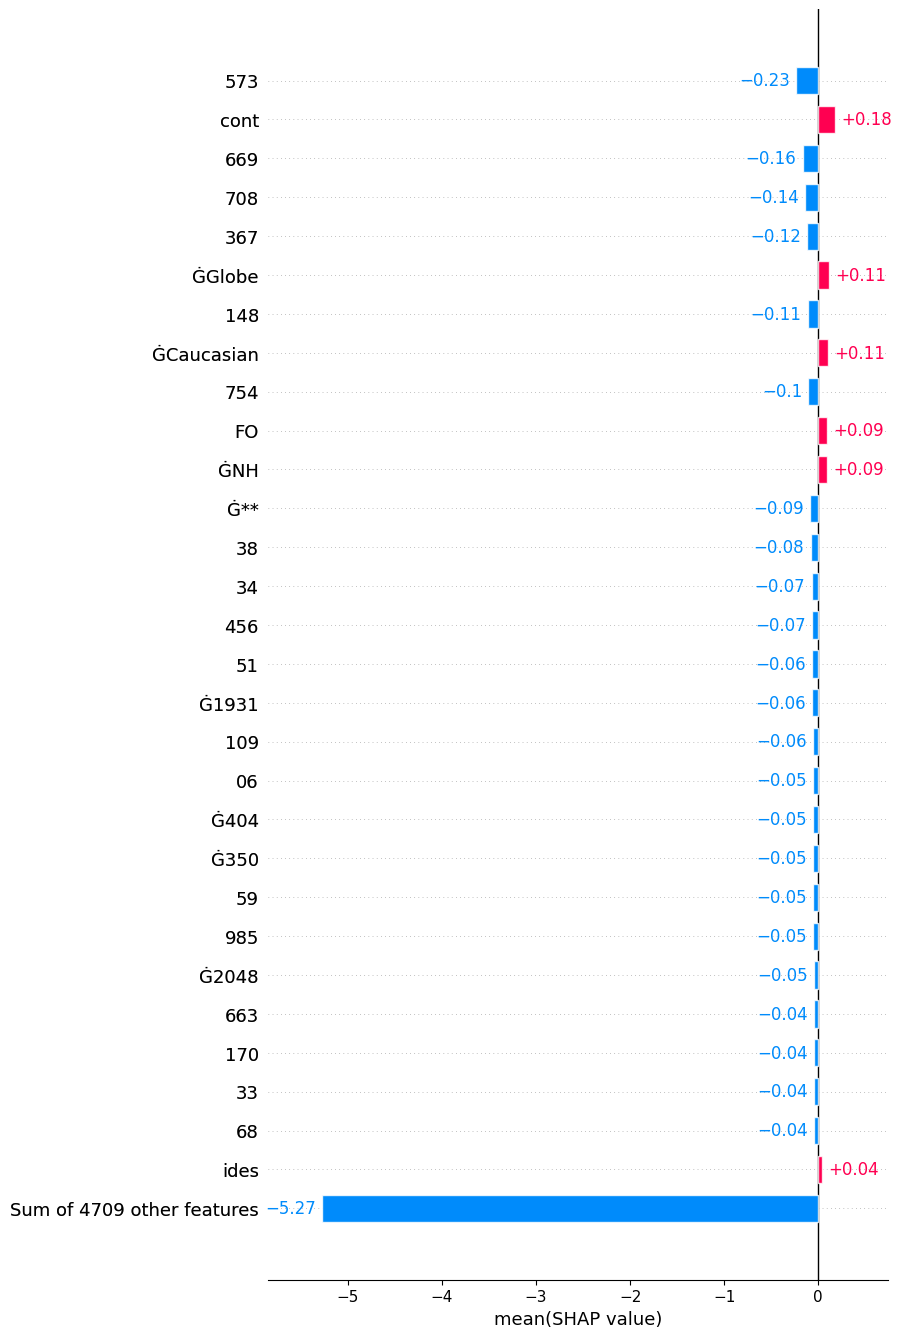

In [12]:
# fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=350)
shap.plots.bar(shap_full[:,:,"Positive"].mean(0), max_display=30)

## Count Word (token) Frequency

In [19]:
from collections import Counter

In [20]:
c_z0_l2_1 = Counter()
c_z1_l2_1 = Counter()
c_z0_pos_l2_1 = Counter()
c_z1_pos_l2_1 = Counter()

In [ ]:
[c_z0_pos_l2_1.update(tokenizer.convert_ids_to_tokens(x)) for x in tokenizer(list(dfs['test'].query(f"dfSource=='{z_Categories[0]}' and label == 1")[txt_col]))['input_ids']]
[c_z1_pos_l2_1.update(tokenizer.convert_ids_to_tokens(x)) for x in tokenizer(list(dfs['test'].query(f"dfSource=='{z_Categories[1]}' and label == 1")[txt_col]))['input_ids']]

In [ ]:
[c_z0_l2_1.update(x) for x in shap_z0_l2_1.data]
[c_z1_l2_1.update(x) for x in shap_z1_l2_1.data]


In [ ]:
c_z0_l2_0 = Counter()
c_z1_l2_0 = Counter()

[c_z0_l2_0.update(x) for x in shap_z0.data]
[c_z1_l2_0.update(x) for x in shap_z1.data]


In [27]:
c_z0_l2_1.most_common(20)

[(' Ġ', 2288),
 (' :', 1608),
 (' .', 1048),
 ('', 1000),
 (' ,', 728),
 (' Ġ[', 711),
 (' Ġin', 509),
 (' ATION', 469),
 (' LOC', 467),
 (' ĠUse', 465),
 (' ĠH', 458),
 (' ]', 430),
 (' IAL', 417),
 (' ISTORY', 417),
 (' Ġto', 358),
 (' Ġuse', 352),
 (' Ġa', 277),
 (' Ġwith', 248),
 (' Ġand', 247),
 (' H', 236)]

In [28]:
c_z1_l2_1.most_common(20)

[(' .', 1675),
 (' **', 1373),
 ('', 1000),
 (' ,', 857),
 (' Ġ[', 784),
 (' :', 775),
 (' Ġ', 765),
 (' ]', 496),
 (' Ġin', 487),
 (' ĠHistory', 455),
 (' Ġand', 438),
 (' Social', 436),
 (' Ġ(', 425),
 (' Ġa', 417),
 (' )', 381),
 (' Ġwith', 343),
 (' Ġof', 332),
 (' Ġto', 277),
 (' Ġuse', 273),
 (' -', 269)]

In [ ]:
[(x[0], x[1]/sum(c_z0_pos_l2_1.values())) for x in c_z0_pos_l2_1.most_common(30)]

In [34]:
[(x[0], x[1]/sum(c_z1_pos_l2_1.values())) for x in c_z1_pos_l2_1.most_common(30)]

[('.', 0.0482392667631452),
 ('**', 0.0385225001722831),
 (',', 0.02728964234029357),
 ('Ġ[', 0.020467231755220177),
 (':', 0.016608090414168563),
 ('Ġin', 0.015367652125973399),
 ('Ġ', 0.013851560884845978),
 ('Ġand', 0.013438081455447592),
 (']', 0.013231341740748397),
 ('Ġof', 0.012542209358417752),
 ('Ġa', 0.01219764316725243),
 ('Ġ(', 0.011853076976087106),
 ('ĠHistory', 0.01054372544965888),
 ('<s>', 0.010336985734959685),
 ('</s>', 0.010336985734959685),
 ('Ġuse', 0.009854593067328233),
 (')', 0.00978567982909517),
 ('Social', 0.009441113637929847),
 ('-', 0.009303287161463718),
 ('Ġto', 0.009234373923230652),
 ('Ġwith', 0.008958720970298394),
 ('Ġhas', 0.007511542967404038),
 ('/', 0.00723589001447178),
 ('ĠHe', 0.007166976776238715),
 ('Ġfor', 0.006960237061539522),
 ('Ġthe', 0.005926538488043553),
 ('Ġyears', 0.005857625249810488),
 ('Ġis', 0.005650885535111295),
 ('2', 0.005306319343945972),
 ('Name', 0.0051684928674798425)]

In [ ]:
c_z0_l2_1[' cont']/sum(c_z0_l2_1.values())

In [ ]:
c_z1_pos_l2_1[' cont']/sum(c_z1_pos_l2_1.values())

In [41]:
for x in c_z0_l2_0:
    if "cig" in x:
        print(x)

 Ġcigarettes
 Ġcig
 cigarettes
 Ġcigars
 cig
 Ġcigarette


In [42]:
c_z0_l2_0[' cig']/sum(c_z0_l2_0.values())

6.3441712926249e-05

In [43]:
c_z1_l2_0[' cig']/sum(c_z1_l2_0.values())

0.0